### Bu Notebooku Yazanlar
- Muhammed Mehmet Gökçe 152120221070
- Ali Yılmaz 152120221108


## Alzheimer Teşhisinde Veri Analizi

### 📋 Veri Hakkında

Bu proje, Alzheimer hastalığını etkileyebilecek çeşitli biyolojik, çevresel ve yaşam tarzı faktörlerini analiz etmeyi amaçlamaktadır. Alzheimer, yaşla birlikte artan karmaşık bir nörodejeneratif hastalık olup, erken teşhis ve risk faktörlerinin anlaşılması hem bireylerin yaşam kalitesini artırmak hem de sağlık sistemlerini daha verimli kılmak açısından büyük önem taşır.

Bu çalışma kapsamında kullanılan veri seti, bireylerin demografik bilgileri, sağlık geçmişi, yaşam tarzı tercihleri ve genetik faktörleri gibi çeşitli değişkenleri içermektedir. Bu değişkenler ile Alzheimer teşhisi arasındaki ilişkiler incelenerek, hastalığın daha iyi anlaşılması ve risk değerlendirme modellerinin geliştirilmesi hedeflenmektedir.

### 📊 Veri Setinin Detayları

- **Age**: Bireyin yaşı. Alzheimer riski yaşla birlikte belirgin şekilde artmaktadır.
  
- **Gender**: Bireyin cinsiyeti. “Male” veya “Female” olarak belirtilmiştir. Bazı araştırmalarda kadınların daha yüksek risk altında olduğu görülmektedir.

- **Education Level**: Bireyin eğitim seviyesi. Eğitim düzeyi genellikle bilişsel rezervi artırarak Alzheimer riskini azaltabilir.

- **BMI (Body Mass Index)**: Vücut kitle indeksi. 18.5 ile 35 arasında değişir. Hem düşük hem yüksek BMI Alzheimer riskini etkileyebilir.

- **Physical Activity Level**: Fiziksel aktivite düzeyi. Düzenli fiziksel aktivite beyin sağlığını olumlu yönde etkileyebilir.

- **Smoking Status**: Sigara kullanımı durumu. Sigara içmek beyin damarlarını etkileyerek Alzheimer riskini artırabilir.

- **Alcohol Consumption**: Alkol tüketimi düzeyi. Aşırı alkol tüketimi bilişsel gerileme ile ilişkilidir.

- **Diabetes**: Diyabet hastalığı varlığı. Diyabet, beyin fonksiyonlarını olumsuz etkileyerek demans riskini artırabilir.

- **Hypertension**: Hipertansiyon (yüksek tansiyon) durumu. Beyin damar sağlığını etkileyerek bilişsel gerilemeye katkıda bulunabilir.

- **Cholesterol Level**: Kolesterol seviyesi. Anormal kolesterol seviyeleri Alzheimer riskini etkileyebilir.

- **Family History of Alzheimer’s**: Ailede Alzheimer hastalığı öyküsü. Genetik yatkınlık önemli bir risk faktörüdür.

- **Cognitive Test Score**: Bilişsel testlerden alınan puan. Düşük skorlar bilişsel bozulma veya demans ile ilişkilidir.

- **Depression Level**: Depresyon seviyesi. Depresyon Alzheimer gelişiminde hem neden hem sonuç olabilir.

- **Sleep Quality**: Uyku kalitesi. Kalitesiz uyku bilişsel işlevleri olumsuz etkileyebilir.

- **Dietary Habits**: Beslenme alışkanlıkları. Sağlıklı beslenme bilişsel gerilemeyi yavaşlatabilir.

- **Air Pollution Exposure**: Hava kirliliğine maruz kalma düzeyi. Uzun süreli maruz kalma beyin sağlığını etkileyebilir.

- **Genetic Risk Factor (APOE-ε4 allele)**: APOE-ε4 gen varyantı taşıma durumu. Bu genetik varyant Alzheimer hastalığı ile güçlü şekilde ilişkilidir.

- **Social Engagement Level**: Sosyal etkileşim düzeyi. Sosyal olarak aktif bireylerde Alzheimer riski daha düşüktür.

- **Stress Levels**: Stres düzeyi. Kronik stres beyin yapısını ve işlevlerini olumsuz etkileyebilir.

- **Alzheimer’s Diagnosis**: Hedef değişken. Bireyin Alzheimer tanısı alıp almadığını gösterir (örn. "Diagnosed", "Not Diagnosed").

Bu veri seti; istatistiksel analiz, görselleştirme ve makine öğrenmesi modelleri ile Alzheimer hastalığına etki eden faktörleri detaylı biçimde analiz ederek erken teşhis ve kişilerin alzheimer yatkınlığı hakkında bilgi oluşturmak amaçlanmıştır



In [1]:
# Gerekli kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

# Grafik ayarları
sns.set_style("whitegrid")  # beyaz arkaplan + gridli yapı daha medikal projelere uygun
plt.rcParams["figure.figsize"] = (12, 6)  # grafiklerin daha büyük görünmesi için

# Sayısal çıktılarda virgülden sonra 3 basamak göster
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
from google.colab import files
uploaded = files.upload()  # bilgisayarından yükleme ekranı açılır

import pandas as pd

# Veri setini oku
df = pd.read_csv("alzheimers_prediction_dataset.csv")

Saving alzheimers_prediction_dataset.csv to alzheimers_prediction_dataset.csv


## Kullanmadığımız verilerin çıkarılması


In [4]:
df.drop(columns=[
    "Country",
    "Employment Status",
    "Marital Status",
    "Income Level",
    "Urban vs Rural Living",
    "Education Level"
], inplace=True)

# İlk 5 satırı görüntüle (temizlenmiş hali)
df.head()

,Age,Gender,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels,Alzheimer’s Diagnosis
0,90,Male,33.000,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,High,No,Low,High,No
1,72,Male,29.900,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,Medium,No,High,High,No
2,86,Female,22.900,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,Medium,No,Low,High,No
3,53,Male,31.200,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,Medium,No,High,Low,No
4,58,Female,30.000,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,High,No,Low,High,No


In [5]:
df.tail()

,Age,Gender,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Stress Levels,Alzheimer’s Diagnosis
74278,60,Female,22.600,High,Former,Never,No,No,High,No,42,Medium,Poor,Average,High,No,Medium,Medium,No
74279,58,Male,30.600,Low,Never,Occasionally,Yes,No,Normal,No,42,Low,Poor,Average,Medium,No,Medium,High,No
74280,57,Female,28.200,Medium,Never,Regularly,No,No,High,Yes,61,Low,Good,Healthy,Low,Yes,High,Low,No
74281,73,Female,29.000,Low,Never,Regularly,No,No,High,No,97,High,Good,Healthy,Low,No,Low,High,No
74282,57,Female,31.700,Low,Current,Regularly,No,No,Normal,No,46,Low,Average,Average,Low,No,Low,Medium,No


In [6]:
print("Veri setinin boyutu (satır, sütun):", df.shape)

Veri setinin boyutu (satır, sütun): (74283, 19)


## Eksik değer kontrolü


In [7]:
# Her sütunda kaç tane eksik değer var?
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Physical Activity Level,0
Smoking Status,0
Alcohol Consumption,0
Diabetes,0
Hypertension,0
Cholesterol Level,0
Family History of Alzheimer’s,0


## Duplicate(Unique) değer kontrolü

In [8]:
df.duplicated().value_counts()

,count
False,74283


In [9]:
duplicate_count = df.duplicated().sum()

print(f"Veri setinde toplam ({duplicate_count}) adet yinelenen (tekrar eden) satır bulunmaktadır.")

Veri setinde toplam (0) adet yinelenen (tekrar eden) satır bulunmaktadır.


*Çıkarım: Duplicated değer yoktur.*

## Veri hakkında genel bilgi


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   74283 non-null  int64  
 1   Gender                                74283 non-null  object 
 2   BMI                                   74283 non-null  float64
 3   Physical Activity Level               74283 non-null  object 
 4   Smoking Status                        74283 non-null  object 
 5   Alcohol Consumption                   74283 non-null  object 
 6   Diabetes                              74283 non-null  object 
 7   Hypertension                          74283 non-null  object 
 8   Cholesterol Level                     74283 non-null  object 
 9   Family History of Alzheimer’s         74283 non-null  object 
 10  Cognitive Test Score                  74283 non-null  int64  
 11  Depression Leve

In [11]:
df.dtypes

,0
Age,int64
Gender,object
BMI,float64
Physical Activity Level,object
Smoking Status,object
Alcohol Consumption,object
Diabetes,object
Hypertension,object
Cholesterol Level,object
Family History of Alzheimer’s,object


## Sayısal ve Object sütunlarının gösterimi

In [12]:
# Sayısal sütunların özeti
print("📊 Sayısal Sütunlar:")
display(df.describe().T)

# Object sütunların özeti
print("\n🔤 Object Sütunlar:")
display(df.describe(include=['object', 'category']).T)

📊 Sayısal Sütunlar:


,count,mean,std,min,25%,50%,75%,max
Age,74283.000,71.965,12.981,50.000,61.000,72.000,83.000,94.000
BMI,74283.000,26.781,4.765,18.500,22.700,26.800,30.900,35.000
Cognitive Test Score,74283.000,64.654,20.153,30.000,47.000,65.000,82.000,99.000



🔤 Object Sütunlar:


,count,unique,top,freq
Gender,74283,2,Female,37249
Physical Activity Level,74283,3,High,24853
Smoking Status,74283,3,Current,24915
Alcohol Consumption,74283,3,Never,24865
Diabetes,74283,2,No,59527
Hypertension,74283,2,No,52134
Cholesterol Level,74283,2,Normal,51973
Family History of Alzheimer’s,74283,2,No,52004
Depression Level,74283,3,Medium,24843
Sleep Quality,74283,3,Good,25145


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,74283.000,NaN,NaN,NaN,71.965,12.981,50.000,61.000,72.000,83.000,94.000
Gender,74283,2,Female,37249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,74283.000,NaN,NaN,NaN,26.781,4.765,18.500,22.700,26.800,30.900,35.000
Physical Activity Level,74283,3,High,24853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking Status,74283,3,Current,24915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol Consumption,74283,3,Never,24865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,74283,2,No,59527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hypertension,74283,2,No,52134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cholesterol Level,74283,2,Normal,51973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family History of Alzheimer’s,74283,2,No,52004,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Sayısal kategorik verileri isimlendirme
Bu projede, veri setinde sayısal kodlarla ifade edilen kategorik değişkenler yer almamaktadır. Tüm kategorik değişkenler, halihazırda metinsel (string) formatta veya doğrudan anlamlı olacak şekilde düzenlenmiştir. Bu nedenle, sayısal olup da kategorik anlam taşıyan bir sütunu string ifadeye dönüştürmeye gerek duyulmamıştır.

Ayrıca, yaş, vücut kitle indeksi (BMI) ve bilişsel test skoru gibi sürekli sayısal değişkenler de analizlerde kullanılmak üzere sayısal biçimde korunmuştur. Bu değişkenlerde de herhangi bir kategorik dönüşüm veya sınıflandırma yapılmamıştır.

Verinin bu yapısı sayesinde, hem analiz hem de modelleme sürecinde doğrudan kullanılabilir nitelikte, temiz bir yapı elde edilmiştir.

# Sayısal veriler

## Sadece sayısal değişkenler içeren dataframe oluşturma

In [14]:
df_num = df.select_dtypes(include = ["float64", "int64"])

In [15]:
df_num.head()

,Age,BMI,Cognitive Test Score
0,90,33.000,90
1,72,29.900,65
2,86,22.900,43
3,53,31.200,81
4,58,30.000,49


In [16]:
df_num.tail()

,Age,BMI,Cognitive Test Score
74278,60,22.600,42
74279,58,30.600,42
74280,57,28.200,61
74281,73,29.000,97
74282,57,31.700,46


In [17]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,74283.000,71.965,12.981,50.000,61.000,72.000,83.000,94.000
BMI,74283.000,26.781,4.765,18.500,22.700,26.800,30.900,35.000
Cognitive Test Score,74283.000,64.654,20.153,30.000,47.000,65.000,82.000,99.000


## Sayısal veriler için histogram grafikleri

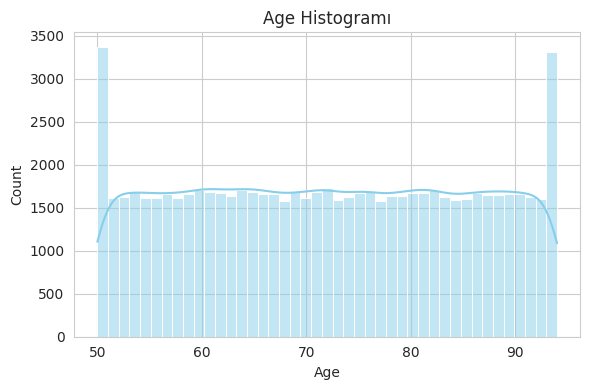

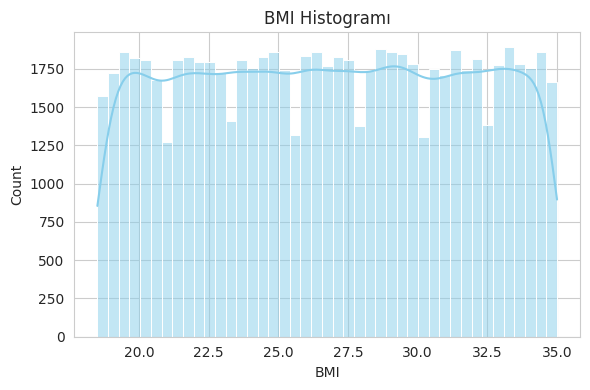

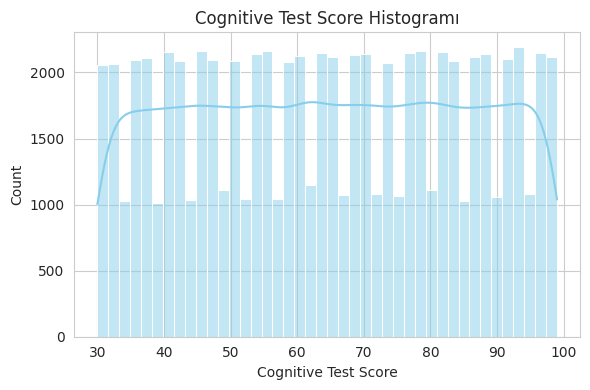

In [18]:
# Sayısal sütunlar
num_cols = ['Age', 'BMI', 'Cognitive Test Score']

# Hepsi için histogram
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f"{col} Histogramı")
    plt.tight_layout()
    plt.show()

## Sayısal veriler için kutu grafikleri

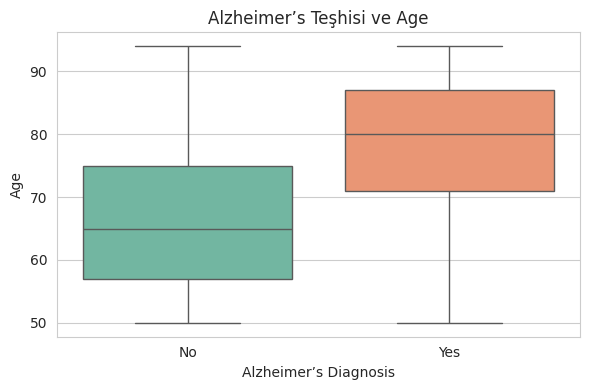

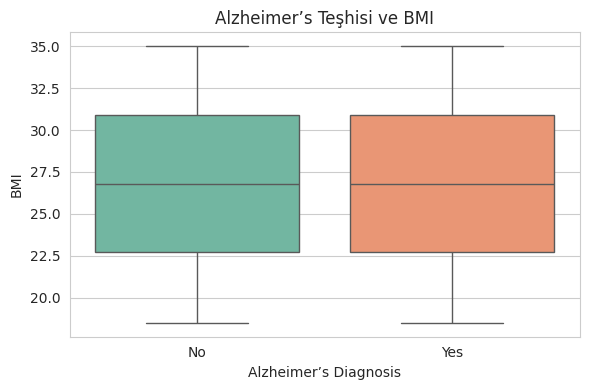

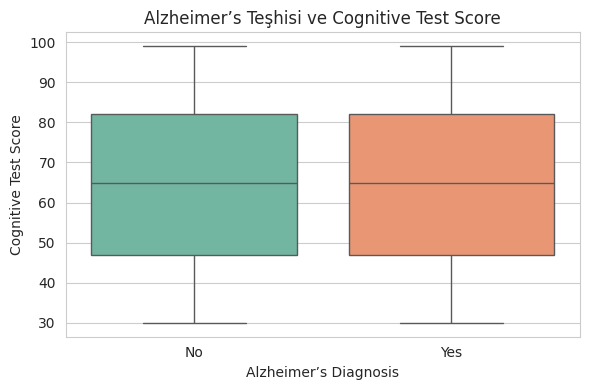

In [19]:
# Boxplotlar
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='Alzheimer’s Diagnosis', y=col, palette="Set2")
    plt.title(f"Alzheimer’s Teşhisi ve {col}")
    plt.tight_layout()
    plt.show()

## Sayısal veriler için scatter plots

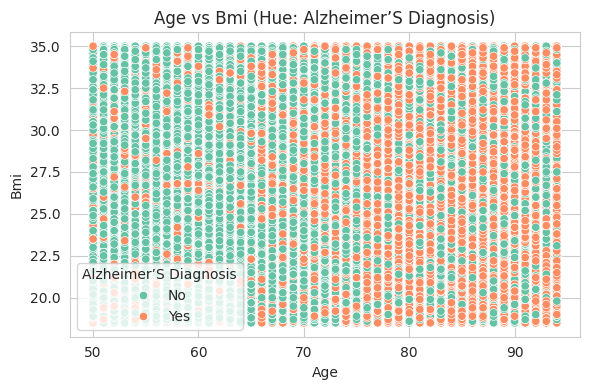

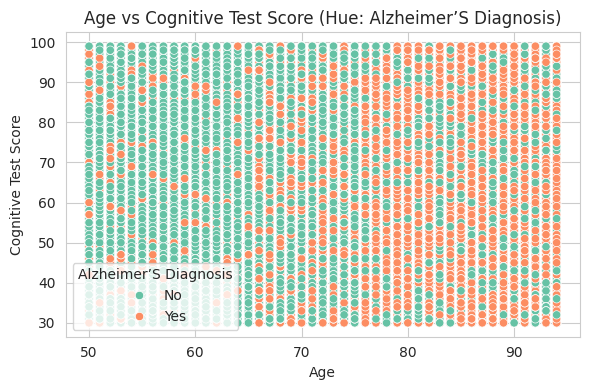

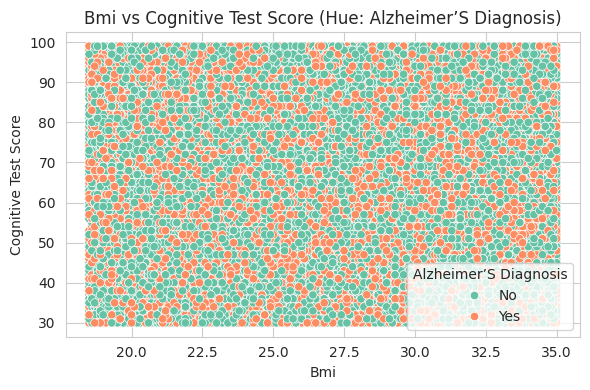

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sütunları normalize et (baş harf büyük, boşlukları temizle)
df.columns = [col.strip().title() for col in df.columns]

# Diagnosis sütununu otomatik bul
diagnosis_col = None
for col in df.columns:
    if 'Diagnosis' in col:
        diagnosis_col = col
        break

# Eğer diagnosis sütunu bulunamazsa hata ver
if diagnosis_col is None:
    raise ValueError("Diagnosis içeren bir sütun bulunamadı.")

# Yeni sütun adları (normalize edilmiş haliyle)
num_cols = ['Age', 'Bmi', 'Cognitive Test Score']

# Tüm ikili kombinasyonlar için scatter plot çiz
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        x = num_cols[i]
        y = num_cols[j]

        # Sütunlar gerçekten var mı diye kontrol
        if x in df.columns and y in df.columns:
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=df, x=x, y=y, hue=diagnosis_col, palette='Set2')
            plt.title(f"{x} vs {y} (Hue: {diagnosis_col})")
            plt.xlabel(x)
            plt.ylabel(y)
            plt.grid(True)
            plt.tight_layout()
            plt.show()

## Sayısal veriler için violin plots

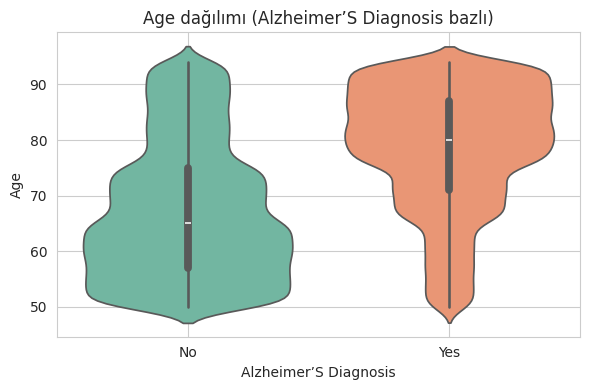

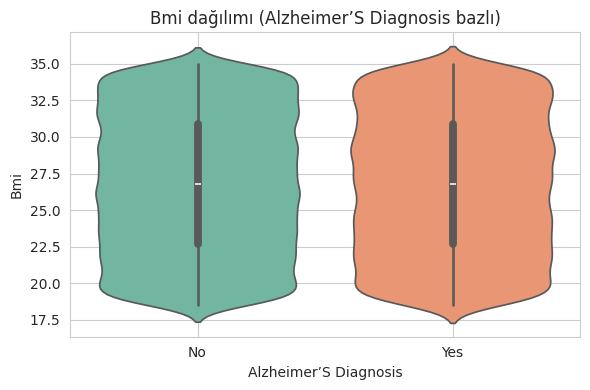

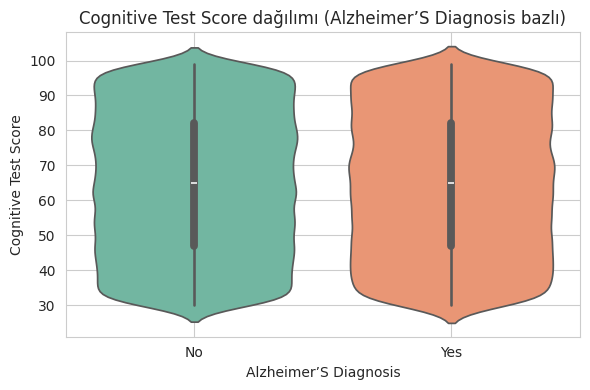

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sütunları normalize et
df.columns = [col.strip().title() for col in df.columns]

# Diagnosis sütununu otomatik bul
diagnosis_col = None
for col in df.columns:
    if 'Diagnosis' in col:
        diagnosis_col = col
        break

if diagnosis_col is None:
    raise ValueError("Diagnosis içeren bir sütun bulunamadı.")

# Dağılımı çizilecek sayısal sütunlar
violin_cols = ['Age', 'Bmi', 'Cognitive Test Score']

# Violin plot çizimi
for col in violin_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.violinplot(data=df, x=diagnosis_col, y=col, palette='Set2')
        plt.title(f"{col} dağılımı ({diagnosis_col} bazlı)")
        plt.xlabel(diagnosis_col)
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{col} sütunu veri setinde bulunamadı.")

## Heatmap ile sayısal verilerin korelasyonu

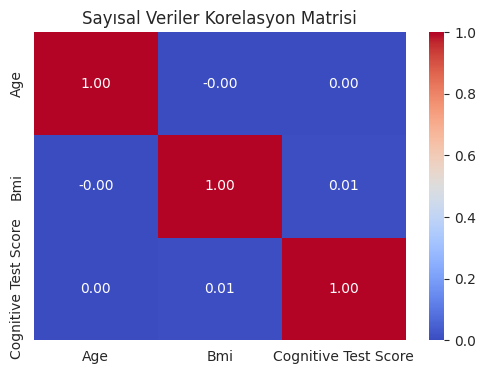

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece sayısal değişkenler
num_cols = ['Age', 'Bmi', 'Cognitive Test Score']

plt.figure(figsize=(6, 4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Sayısal Veriler Korelasyon Matrisi")
plt.show()

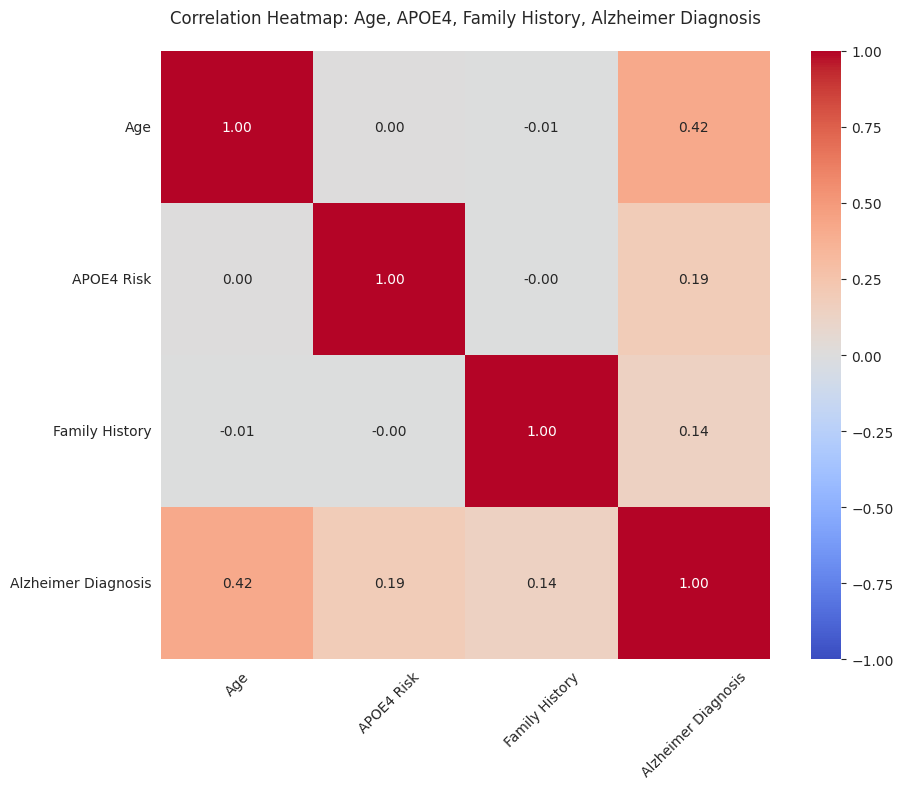

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri setini oku
df = pd.read_csv('alzheimers_prediction_dataset.csv')

# İlgili sütunları seç
columns_of_interest = [
    'Age',
    'Genetic Risk Factor (APOE-ε4 allele)',
    'Family History of Alzheimer’s',
    'Alzheimer’s Diagnosis'
]

# Yeni dataframe oluştur
data = df[columns_of_interest].copy()

# Kategorik sütunları sayısala çevir (0/1)
data['Genetic Risk Factor (APOE-ε4 allele)'] = data['Genetic Risk Factor (APOE-ε4 allele)'].map({'Yes': 1, 'No': 0})
data['Family History of Alzheimer’s'] = data['Family History of Alzheimer’s'].map({'Yes': 1, 'No': 0})
data['Alzheimer’s Diagnosis'] = data['Alzheimer’s Diagnosis'].map({'Yes': 1, 'No': 0})

# Sütun adlarını sadeleştir
data.columns = ['Age', 'APOE4 Risk', 'Family History', 'Alzheimer Diagnosis']

# Korelasyon matrisi oluştur
correlation_matrix = data.corr()

# Korelasyon ısı haritası çiz
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, fmt='.2f')
plt.title('Correlation Heatmap: Age, APOE4, Family History, Alzheimer Diagnosis', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap_fixed.png')
plt.show()


## KDE plot ile Alzheimer ve yaş arasındaki ilişkinin yoğunluğunun gösterimi

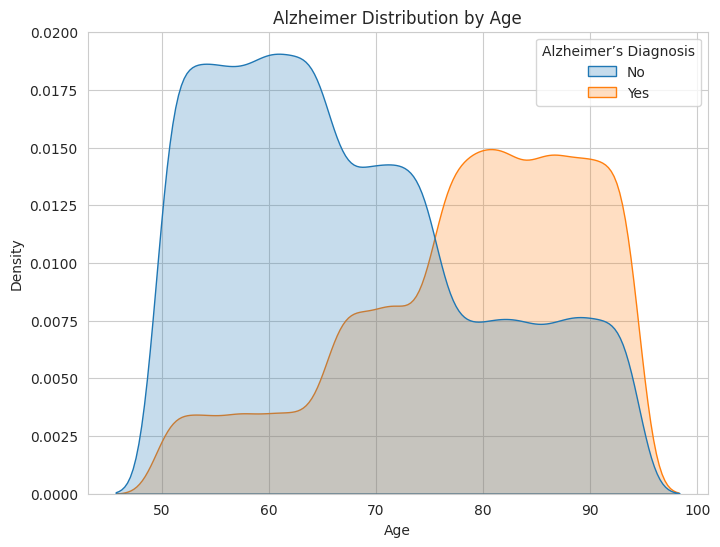

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


target_col = [col for col in df.columns if "Diagnosis" in col][0]

plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Age', hue=target_col, fill=True)
plt.title('Alzheimer Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

**Çıkarım**: Yaş arttıkça alzheimer görülme oranı artar.

# Kategorik veriler

## Object tipini kategoriye çevirme
Veri setindeki metinsel (object) sütunlar, kategorik anlam taşıdığı için category veri tipine dönüştürülmüştür. Bu işlem, veri analiz sürecinde bellek verimliliğini artırmakta ve kategorik verilerin istatistiksel özetlerinin daha anlamlı olmasını sağlamaktadır. Dönüştürme sonrası sadece kategorik değişkenleri içeren bir DataFrame oluşturulmuştur:

In [25]:
object_columns = df.select_dtypes(include=['object']).columns
df[object_columns] = df[object_columns].apply(lambda x: x.astype('category'))

In [26]:
from IPython.display import display, HTML

# Sadece kategorik sütunları al
categorical_columns = df.select_dtypes(include='category').dtypes

# HTML tablosu olarak görüntüle
display(HTML(categorical_columns.to_frame().to_html()))


,0
Country,category
Gender,category
Physical Activity Level,category
Smoking Status,category
Alcohol Consumption,category
Diabetes,category
Hypertension,category
Cholesterol Level,category
Family History of Alzheimer’s,category
Depression Level,category


## Sadece kategorik değişkenleri içeren dataframe oluşturma

In [27]:
kat_df = df.select_dtypes(include=["category"])

In [28]:
kat_df.head()

,Country,Gender,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Depression Level,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,Male,Medium,Never,Occasionally,No,No,Normal,No,Low,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,Male,Medium,Former,Never,No,No,Normal,No,Low,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,Female,High,Current,Occasionally,No,Yes,Normal,No,High,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,Male,Low,Never,Regularly,Yes,No,Normal,No,Medium,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,Female,High,Former,Never,Yes,No,Normal,No,High,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


In [29]:
kat_df.tail()

,Country,Gender,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Depression Level,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
74278,Russia,Female,High,Former,Never,No,No,High,No,Medium,...,Average,High,Unemployed,Widowed,No,Medium,High,Medium,Rural,No
74279,UK,Male,Low,Never,Occasionally,Yes,No,Normal,No,Low,...,Average,Medium,Unemployed,Single,No,Medium,High,High,Rural,No
74280,Spain,Female,Medium,Never,Regularly,No,No,High,Yes,Low,...,Healthy,Low,Employed,Single,Yes,High,Low,Low,Rural,No
74281,Brazil,Female,Low,Never,Regularly,No,No,High,No,High,...,Healthy,Low,Employed,Widowed,No,Low,Low,High,Rural,No
74282,Norway,Female,Low,Current,Regularly,No,No,Normal,No,Low,...,Average,Low,Unemployed,Single,No,Low,Medium,Medium,Urban,No


# Gruplandırılmış Sütun Grafikleri

## Cinsiyete göre Alzheimer tanısı sayısı ve yoğunluğu

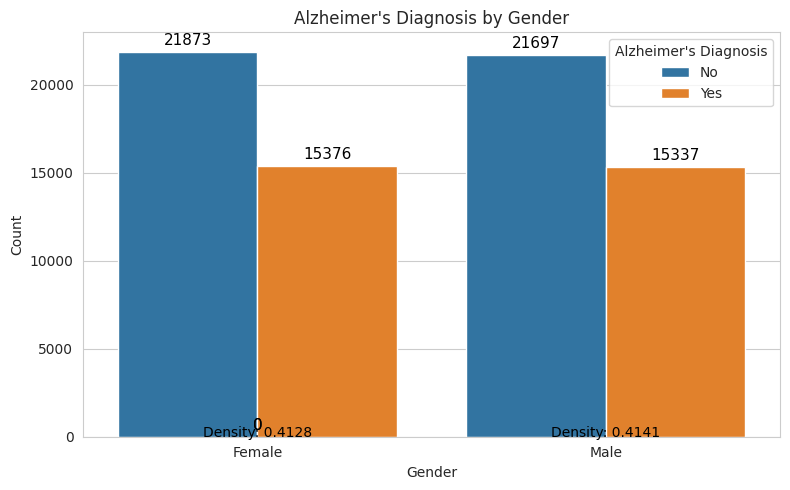

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Örnek: df'nin zaten yüklü olduğunu varsayıyoruz
# Sütun adlarını temizle (büyük/küçük, özel karakter, boşluk vs.)
df.columns = (
    df.columns
    .str.replace("’", "'", regex=False)
    .str.replace("‘", "'", regex=False)
    .str.replace("`", "'", regex=False)
    .str.strip()
)

# 'diagnosis' içeren sütun adını otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Gender',
    hue=diagnosis_col,
    order=sorted(df['Gender'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Alt tarafa her cinsiyet için yoğunluk (density) yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Gender'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Bu grafiğe göre cinsiyet, Alzheimer riski belirlemede belirleyici bir faktör gibi görünmemekle birlikte, çok küçük bir farkla erkekler bir nebze daha fazla risk altındadır.


## BMI'ye göre Alzheimer tanısı sayısı ve yoğunluğu

In [32]:
# BMI aralıklarını belirle
bmi_bins = [18, 20, 22, 24, 26, 28, 30, 32, 34, 36]
bmi_labels = ['18-20', '20-22', '22-24', '24-26', '26-28', '28-30', '30-32', '32-34', '34-36']

# Yeni bir sütun oluştur ve kategorilere ayır
df['Bmi Group'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

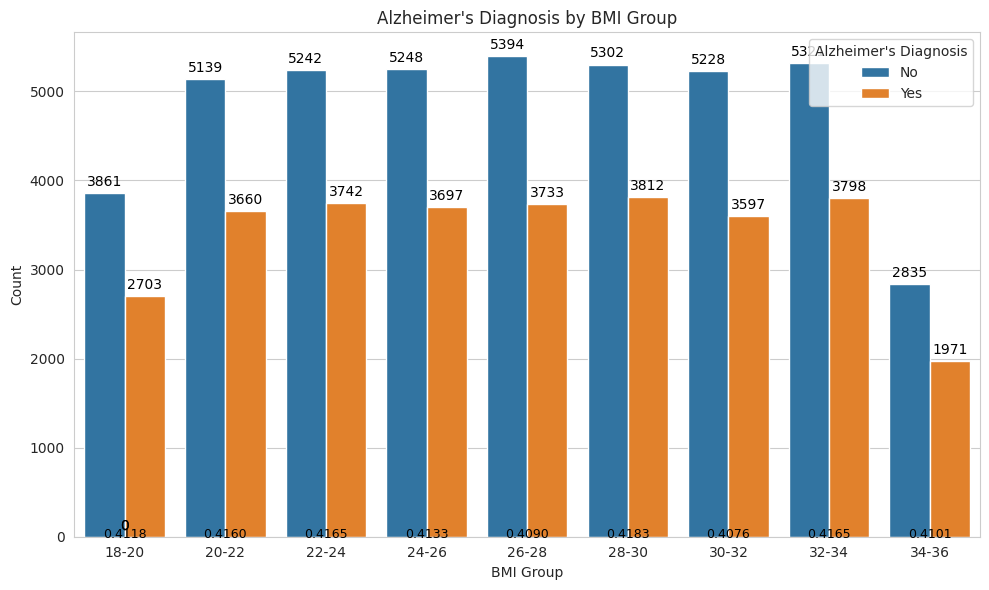

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını düzelt (varsa özel karakter)
df.columns = (
    df.columns
    .str.replace("’", "'", regex=False)
    .str.replace("‘", "'", regex=False)
    .str.replace("`", "'", regex=False)
    .str.strip()
)

# Alzheimer's Diagnosis sütununu otomatik tespit et
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# BMI aralıklarını ve etiketlerini tanımla
bmi_bins = [18, 20, 22, 24, 26, 28, 30, 32, 34, 36]
bmi_labels = ['18-20', '20-22', '22-24', '24-26', '26-28', '28-30', '30-32', '32-34', '34-36']

# BMI Group sütununu oluştur
df['Bmi Group'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Grafik çizimi
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x='Bmi Group',
    hue=diagnosis_col,
    order=bmi_labels  # Sıralama için
)

plt.title("Alzheimer's Diagnosis by BMI Group")
plt.xlabel("BMI Group")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=10, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Altına yoğunluk (density) yaz
tick_labels = bmi_labels

for idx, label in enumerate(tick_labels):
    category_data = df[df['Bmi Group'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'{density:.4f}', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

**Çıkarım:** Bu verilere göre, Alzheimer riski açısından BMI değerlerinde belirgin bir doğrusal ilişki görülmemektedir.


## Fiziksel aktivite seviyesine göre Alzheimer tanısı sayısı ve yoğunluğu

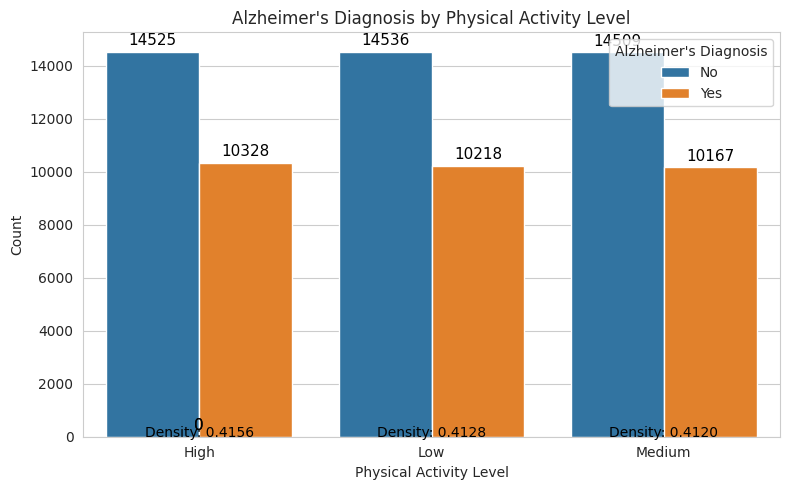

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını temizle (boşluk ve özel karakterlerden arındır)
df.columns = (
    df.columns
    .str.replace("’", "'", regex=False)
    .str.replace("‘", "'", regex=False)
    .str.replace("`", "'", regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Physical Activity Level',
    hue=diagnosis_col,
    order=sorted(df['Physical Activity Level'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üst kısma yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesapla ve çubuğun altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Physical Activity Level'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Bu verilere göre, fiziksel aktivite düzeyinin Alzheimer riski üzerinde belirgin ve doğrusal bir etkisi gözlemlenmemektedir.


## Sigara içme durumuna göre Alzheimer tanısı sayısı ve yoğunluğu


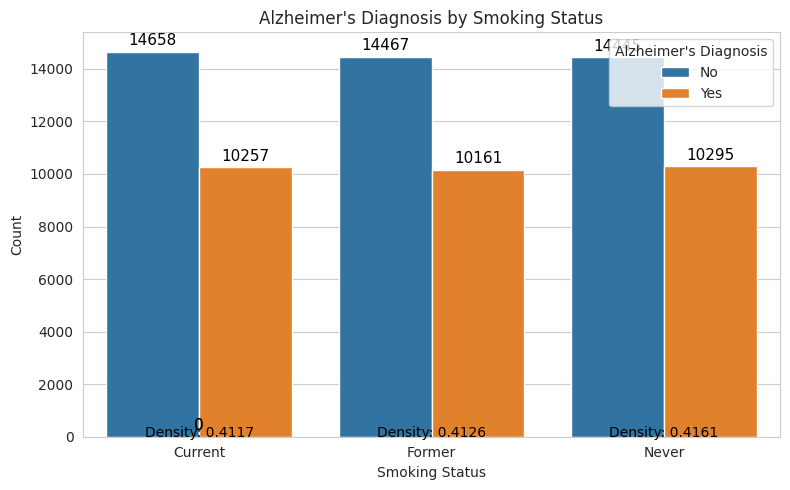

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını temizle (boşluk ve özel karakterlerden arındır)
df.columns = (
    df.columns
    .str.replace("’", "'", regex=False)  # Tırnak işaretlerini düzelt
    .str.replace("‘", "'", regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_cols = [col for col in df.columns if "diagnosis" in col.lower()]
if diagnosis_cols:  # Eğer diagnosis ile ilgili bir sütun bulunursa
    diagnosis_col = diagnosis_cols[0]
else:
    print("Alzheimer's diagnosis column not found. Please check the column names.")
    diagnosis_col = None  # Burada None atanabilir veya kullanıcıdan manuel sütun adı istenebilir

# Eğer diagnosis sütunu varsa, grafik çizimi yap
if diagnosis_col:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(
        data=df,
        x='Smoking Status',
        hue=diagnosis_col,
        order=sorted(df['Smoking Status'].dropna().unique())
    )

    plt.title("Alzheimer's Diagnosis by Smoking Status")
    plt.xlabel("Smoking Status")
    plt.ylabel("Count")
    plt.legend(title="Alzheimer's Diagnosis")

    # Sayıları üst kısma yaz
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=11, color='black',
                        xytext=(0, 8), textcoords='offset points')

    # Yoğunluk (density) hesapla ve çubuğun altına yaz
    tick_labels = [label.get_text() for label in ax.get_xticklabels()]

    for idx, label in enumerate(tick_labels):
        category_data = df[df['Smoking Status'] == label]
        alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
        total_count = category_data.shape[0]
        density = alz_count / total_count if total_count > 0 else 0
        ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()
else:
    print("Alzheimer diagnosis column not found. Unable to plot.")


Çıkarım: Bu verilere göre devamlı sigara içenlerin, eskiden içenlere göre Alzheimer'a yakalanma riski daha düşüktür. Eskiden içenlerin ise hiç sigara içmemişlere kıyasla Alzheimer riski daha düşüktür.


##  Alkol tüketimine göre Alzheimer tanısı sayısı ve yoğunluğu


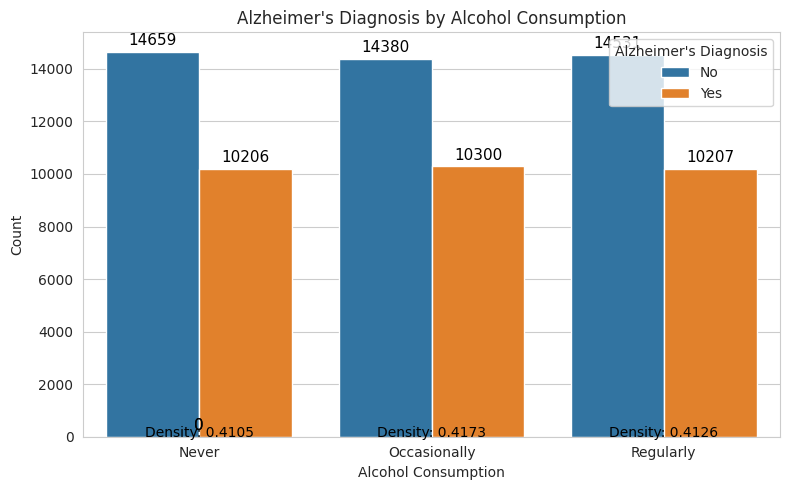

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarındaki özel karakterleri düzelt (gerekiyorsa)
df.columns = df.columns.str.replace('’', "'", regex=False)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Alcohol Consumption',
    hue=diagnosis_col,
    order=sorted(df['Alcohol Consumption'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Alcohol Consumption")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üst kısma yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesaplama ve yazma
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Alcohol Consumption'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


Çıkarım: Bu verilere göre, Alzheimer ve alkol tüketimi arasında doğrusal ya da mantıksal bir ilişki gözlemlenememektedir.


##  Diabet durumuna göre Alzheimer tanısı sayısı ve yoğunluğu


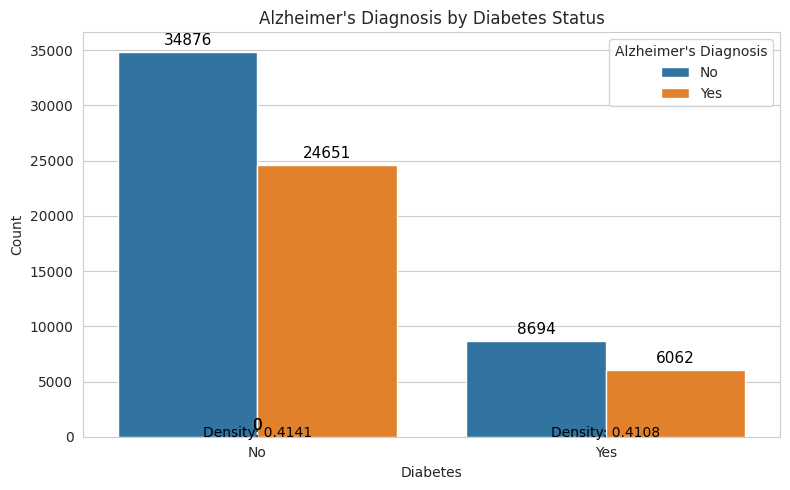

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarındaki özel karakterleri düzelt (gerekiyorsa)
df.columns = df.columns.str.replace('’', "'", regex=False)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Diabetes',
    hue=diagnosis_col,
    order=sorted(df['Diabetes'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üst kısma yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesaplama ve yazma
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Diabetes'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Diabet ve alzheimer arasında doğrusal ya da mantıksal bir bağlantı gözlenmemiştir.

In [40]:
import plotly.express as px
import pandas as pd

# Örnek: df zaten daha önce tanımlanmış olmalı
# Sütun adlarını normalize et (gizli boşluklar, özel kesme işaretleri vb.)
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme işaretini düzleştir
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # boşluk karakterlerini temizle

# Verileri filtrele: Alzheimer teşhisi 'Yes' olanlardan, Diabetes sütununu al
diabetes_data = df[df["Alzheimer's Diagnosis"] == 'Yes']['Diabetes'].value_counts()

# Pie grafiğini oluştur
fig = px.pie(values=diabetes_data,
             names=diabetes_data.index,
             template='plotly_dark',
             title="Does Diabetes Affect Alzheimer’s Diagnosis?")

# Yüzde ve etiket göster
fig.update_traces(textinfo='label+percent')

# Grafiği göster
fig.show()


alzheimer hastası kişilerin çoğunda diyabet yok


##  Hipertansiyon durumuna göre Alzheimer tanısı sayısı ve yoğunluğu


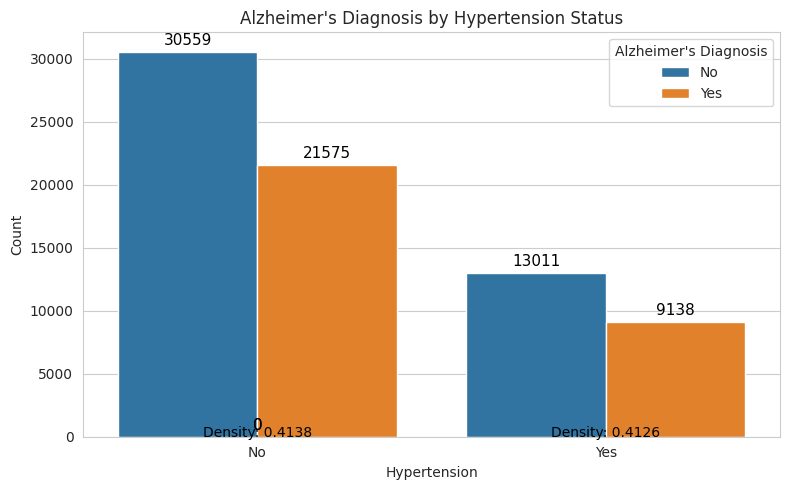

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarındaki özel karakterleri düzelt (gerekiyorsa)
df.columns = df.columns.str.replace('’', "'", regex=False)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Hypertension',
    hue=diagnosis_col,
    order=sorted(df['Hypertension'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Hypertension Status")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üst kısma yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesaplama ve yazma
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Hypertension'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Alzheimer ve hipertansiyon arasında doğrusal ya da mantıksal herhangi bir bağlantı gözlenmemiştir.

In [44]:
import plotly.express as px

# Sütun adlarını normalize et (kesme işaretleri ve boşlukları düzelt)
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme işareti -> düz kesme
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # fazla boşlukları temizle

# 'Alzheimer's Diagnosis' = 'Yes' olanlardan 'Hypertension' sütununu al ve dağılımı hesapla
hypertension_data = df[df["Alzheimer's Diagnosis"] == 'Yes']['Hypertension'].value_counts()

# Pie grafiğini oluştur
fig = px.pie(values=hypertension_data,
             names=hypertension_data.index,
             template='plotly_dark',
             title="Does Hypertension Affect Alzheimer’s Diagnosis?")

# Etiket ve yüzdeyi göster
fig.update_traces(textinfo='label+percent')

# Grafiği göster
fig.show()


alzheimer olan bireylerin çoğunda hipertansiyon hastalığı yok


##  Kolesterol seviyesine göre Alzheimer tanısı sayısı ve yoğunluğu


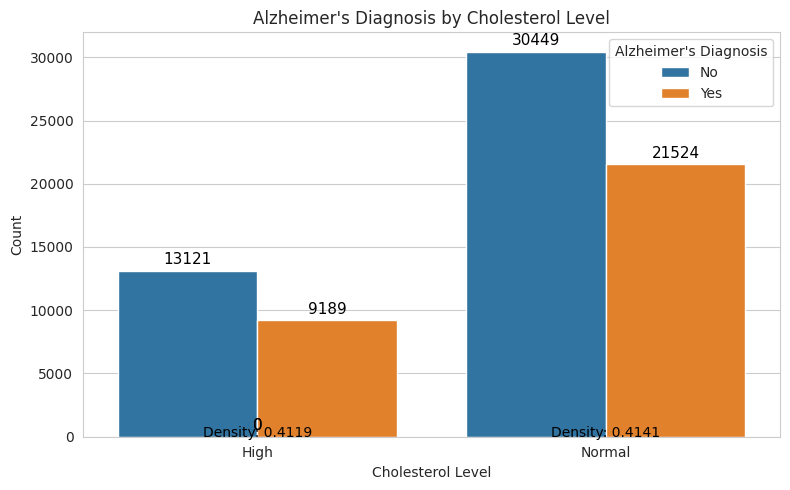

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarındaki özel karakterleri düzelt (gerekiyorsa)
df.columns = df.columns.str.replace('’', "'", regex=False)

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Cholesterol Level',
    hue=diagnosis_col,
    order=sorted(df['Cholesterol Level'].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üst kısma yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesaplama ve yazma
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df['Cholesterol Level'] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:**kolesterol seviyesi ve alzheimer arasında net bir bağlantı görülmemiştir.

In [47]:
import plotly.express as px

# Sütun adlarını normalize et (tipografik kesme işaretlerini ve fazla boşlukları düzelt)
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # fazla boşlukları temizleme

# 'Alzheimer's Diagnosis' = 'Yes' olanlardan 'Cholesterol Level' sütununu al ve dağılımını hesapla
cholesterol_data = df[df["Alzheimer's Diagnosis"] == 'Yes']['Cholesterol Level'].value_counts()

# Pie grafiğini oluştur
fig = px.pie(values=cholesterol_data,
             names=cholesterol_data.index,
             template='plotly_dark',
             title="Does Cholesterol Level Affect Alzheimer’s Diagnosis?")

# Etiket ve yüzde göster
fig.update_traces(textinfo='label+percent')

# Grafiği göster
fig.show()


Çıkarım: Alzhimer olan bireylerin çoğunun kolesterol seviyesi normaldir.


##  Ailede Alzheimer geçmişi durumuna göre Alzheimer tanısı sayısı ve yoğunluğu


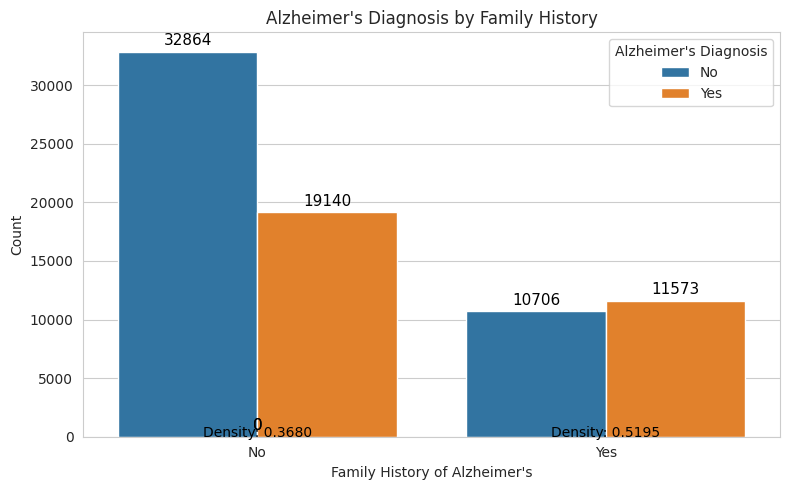

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et (kesme işareti ve boşlukları düzelt)
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme düzelt
df.columns = df.columns.str.replace("'", "", regex=False)       # kesme işaretlerini kaldır
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Aile geçmişi sütununu otomatik bul
family_history_col = [col for col in df.columns if "family history" in col.lower() and "alzheimer" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))

# Sayım grafiği
ax = sns.countplot(
    data=df,
    x=family_history_col,
    hue=diagnosis_col,
    order=sorted(df[family_history_col].dropna().unique())
)

plt.title("Alzheimer's Diagnosis by Family History")
plt.xlabel("Family History of Alzheimer's")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) bilgilerini x ekseninin altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[family_history_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


##  Bilişsel test puanına göre Alzheimer tanısı sayısı ve yoğunluğu


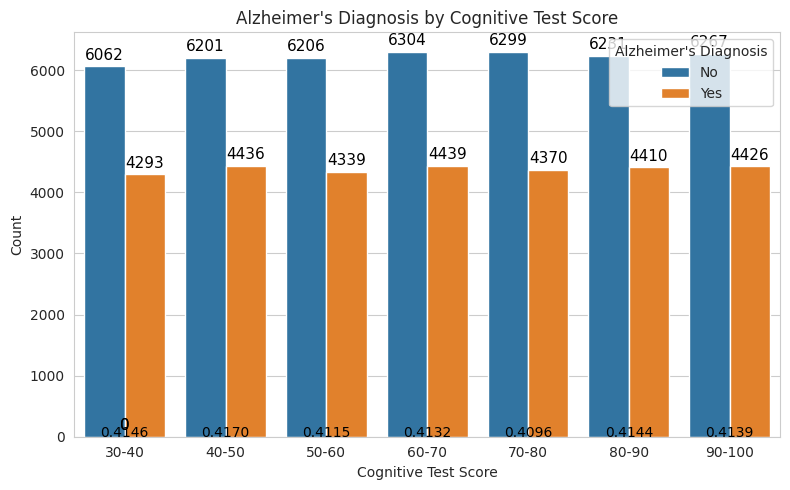

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme işareti düzelt
df.columns = df.columns.str.replace("'", "", regex=False)       # düz kesme işaretini kaldır
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # fazla boşlukları temizle

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Cognitive Test Score sütununu otomatik bul
cognitive_score_col = [col for col in df.columns if "cognitive" in col.lower() and "score" in col.lower()][0]

# Cognitive Test Score için aralıkları belirle
bins = [30, 40, 50, 60, 70, 80, 90, 100]
labels = ['30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']

# Değerleri aralıklara ayır
df[cognitive_score_col] = pd.cut(df[cognitive_score_col], bins=bins, labels=labels, right=False)

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=cognitive_score_col,
    hue=diagnosis_col,
    order=labels
)

plt.title("Alzheimer's Diagnosis by Cognitive Test Score")
plt.xlabel("Cognitive Test Score")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları üstte göster
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunlukları alt satıra yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[cognitive_score_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'{density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** cognitive (bilişsel) test in alzheimer risk tahmini üzerinde doğrusal bir bağlantısı gözlemlenmemiştir.

##  Depresyon seviyesine göre Alzheimer tanısı sayısı ve yoğunluğu


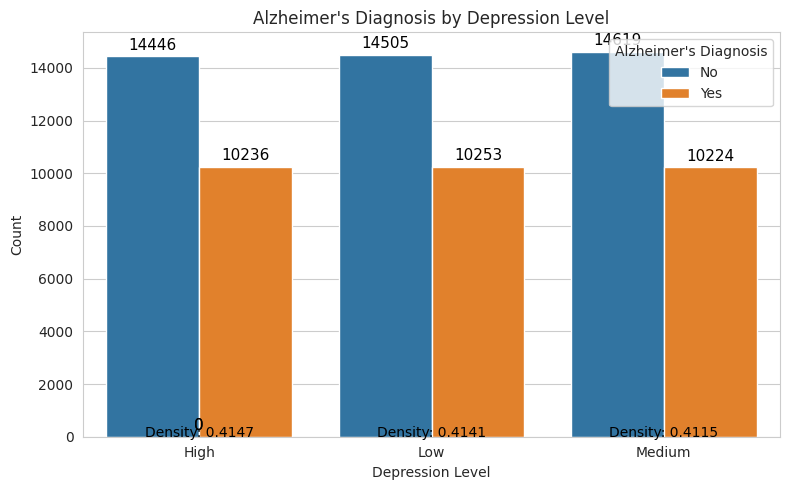

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # tipografik kesme düzelt
df.columns = df.columns.str.replace("'", "", regex=False)       # düz kesmeleri kaldır
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Depression Level sütununu otomatik bul
depression_col = [col for col in df.columns if "depression" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=depression_col,
    hue=diagnosis_col,
    order=sorted(df[depression_col].dropna().unique())  # Kategorileri sırala
)

plt.title("Alzheimer's Diagnosis by Depression Level")
plt.xlabel("Depression Level")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk oranlarını çubukların altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[depression_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Alzheimer ve depresyon seviyesi arasında bir bağlantı gözlemlenmemiştir.

##  Uyku kalitesine göre Alzheimer tanısı sayısı ve yoğunluğu


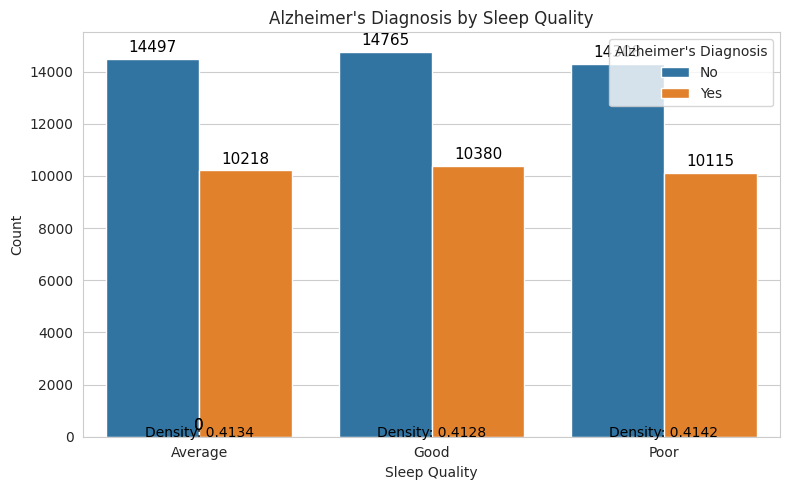

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)       # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Sleep Quality sütununu otomatik bul
sleep_quality_col = [col for col in df.columns if "sleep" in col.lower() and "quality" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=sleep_quality_col,
    hue=diagnosis_col,
    order=sorted(df[sleep_quality_col].dropna().unique())  # 'Sleep Quality' içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk oranlarını çubukların altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[sleep_quality_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:**Alzheimer ve uyku kalitesi arasında bir bağlantı görülmemiştir.

##  Beslenme alışkanlıklarına göre Alzheimer tanısı sayısı ve yoğunluğu


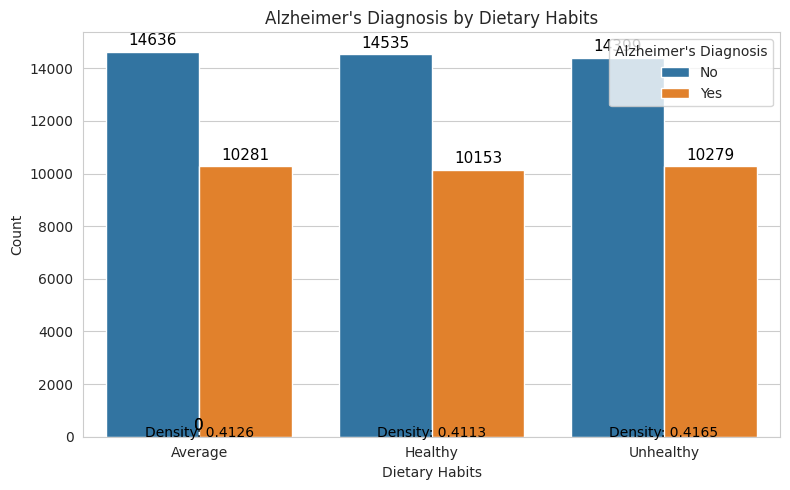

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)       # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Dietary Habits sütununu otomatik bul
dietary_habits_col = [col for col in df.columns if "diet" in col.lower() and "habits" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=dietary_habits_col,
    hue=diagnosis_col,
    order=sorted(df[dietary_habits_col].dropna().unique())  # 'Dietary Habits' içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Dietary Habits")
plt.xlabel("Dietary Habits")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk oranlarını çubukların altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[dietary_habits_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


**Çıkarım:** Alzheimer ve beslenme alışkanlığı arasında az da olsa bir bağlantı incelenmiştir sağlıklıdan sağlıksıza doğru küçük bir risk artışı incelenmiştir.


## Hava kirliliğine maruz kalma durumuna göre Alzheimer tanısı sayısı ve yoğunluğu


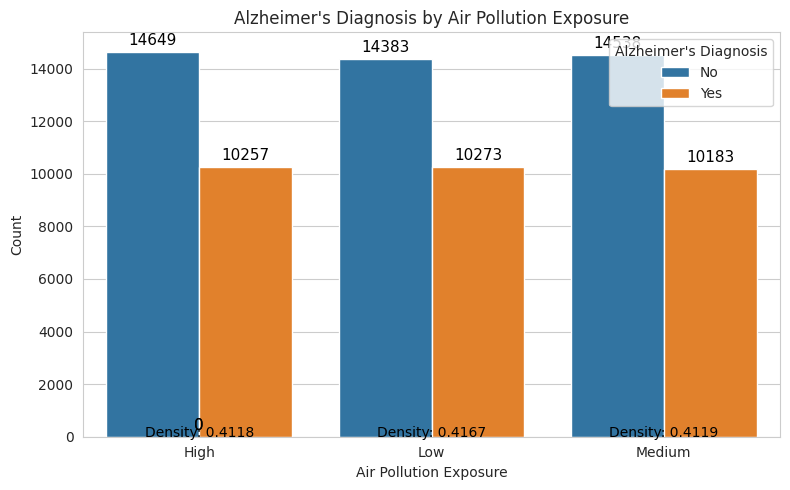

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)       # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Air Pollution Exposure sütununu otomatik bul
pollution_col = [col for col in df.columns if "air" in col.lower() and "pollution" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=pollution_col,
    hue=diagnosis_col,
    order=sorted(df[pollution_col].dropna().unique())  # 'Air Pollution Exposure' içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Air Pollution Exposure")
plt.xlabel("Air Pollution Exposure")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları çubukların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk oranlarını çubukların altına yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[pollution_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


*Çıkarım: alzheimer ve hava kirliliği arasında küçükde olsa beklenenin aksine ters bir orantı incelenmiştir.*

##  Genetik Risk Faktörü (APOE-ε4 aleli)'ne göre Alzheimer tanısı sayısı ve yoğunluğu


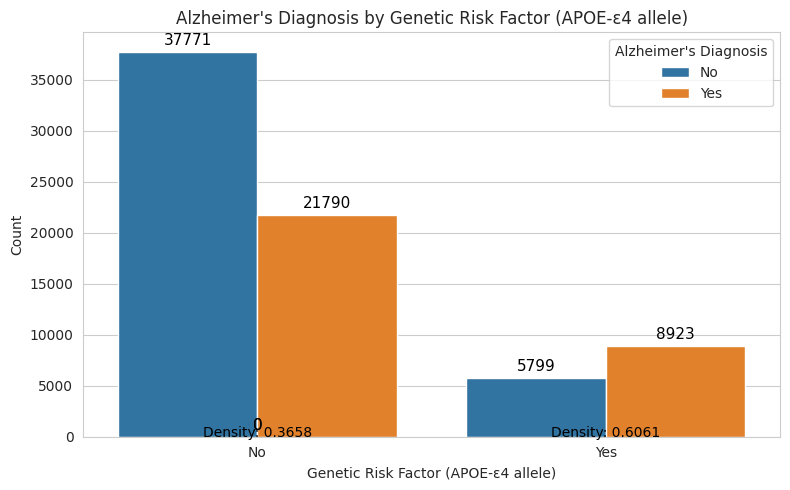

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('\u2019', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)       # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Genetik Risk Faktörü (APOE-ε4 allele) sütununu otomatik bul
genetic_risk_col = [col for col in df.columns if "genetic" in col.lower() and "risk" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=genetic_risk_col,  # Genetik risk faktörü sütunu
    hue=diagnosis_col,  # Alzheimer teşhis sütunu
    order=sorted(df[genetic_risk_col].dropna().unique())  # Genetik risk faktörü içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Genetic Risk Factor (APOE-ε4 allele)")  # Kesme işareti düzeltildi
plt.xlabel("Genetic Risk Factor (APOE-ε4 allele)")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları barların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Bar altına yoğunluk (density) yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[genetic_risk_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


*Çıkarım: Alzheimer ve apor-4 allele geni arasında net bir ilişki gözlenmiştir apoe4 geni aktif bireylerin aktif olmayanlara göre neredeyse 2 kat alzheimer riskine sahip olduğu incelenmiştir.*

##  Sosyal katılım düzeyine göre Alzheimer tanısı sayısı ve yoğunluğu


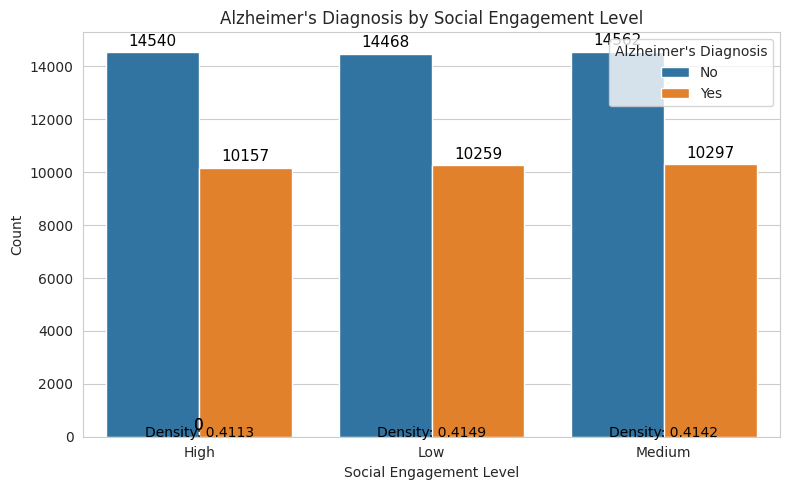

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('’', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)  # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Sosyal katılım düzeyi sütununu otomatik bul
engagement_col = [col for col in df.columns if "engagement" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=engagement_col,  # Sosyal katılım düzeyi sütunu
    hue=diagnosis_col,  # Alzheimer teşhis sütunu
    order=sorted(df[engagement_col].dropna().unique())  # Sosyal katılım düzeyi içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Social Engagement Level")  # Kesme işareti düzeltildi
plt.xlabel("Social Engagement Level")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları barların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Bar altına yoğunluk (density) yaz
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[engagement_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


*Çıkarım: Alzheimer ve sosyallik arasında bir bağlantı gözlenmemiştir.*

##  Stres seviyesine göre Alzheimer tanısı sayısı ve yoğunluğu


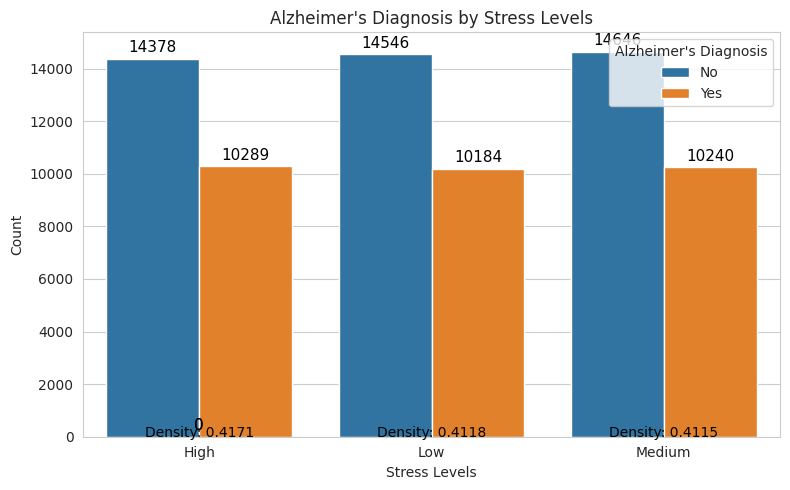

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sütun adlarını normalize et
df.columns = df.columns.str.replace('’', "'", regex=False)  # Tipografik kesme işareti düzeltme
df.columns = df.columns.str.replace("'", "", regex=False)  # Düz kesmeleri kaldırma
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()  # Fazla boşlukları kaldır

# Alzheimer teşhis sütununu otomatik bul
diagnosis_col = [col for col in df.columns if "diagnosis" in col.lower()][0]

# Stress Levels sütununu otomatik bul
stress_col = [col for col in df.columns if "stress" in col.lower() and "level" in col.lower()][0]

# Grafik çizimi
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x=stress_col,  # Stress Levels sütunu
    hue=diagnosis_col,  # Alzheimer teşhis sütunu
    order=sorted(df[stress_col].dropna().unique())  # Stress Levels içeriğini sıralıyoruz
)

plt.title("Alzheimer's Diagnosis by Stress Levels")  # Kesme işareti düzeltildi
plt.xlabel("Stress Levels")
plt.ylabel("Count")
plt.legend(title="Alzheimer's Diagnosis")

# Sayıları barların üstüne yaz
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points')

# Yoğunluk (density) hesaplama ve yazma
tick_labels = [label.get_text() for label in ax.get_xticklabels()]

for idx, label in enumerate(tick_labels):
    category_data = df[df[stress_col] == label]
    alz_count = category_data[category_data[diagnosis_col] == 'Yes'].shape[0]
    total_count = category_data.shape[0]
    density = alz_count / total_count if total_count > 0 else 0
    ax.text(idx, -10, f'Density: {density:.4f}', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


*Çıkarım: Alzheimer ve stres seviyesi arasında bir bağlantı gözlemlenmemiştir.*

# **Risk Tahmini İçin Yapılanlar**

Veri setindeki her sütun için yoğunluk hesaplamaları ve risk tahminine yönelik risk ağırlık katsayıları belirlenmiştir. Ayrıca, XGBoost modeli ile veri seti eğitilmiş ve kullanıcıdan alınan girdilerle kişiye özel risk tahminleri yapılabilmesi sağlanmıştır.


risk ağırlık katsayılarının hesaplanması.

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Veri setini oku
print("Veri seti okunuyor...")
df = pd.read_csv('alzheimers_prediction_dataset.csv')

# Gereksiz sütunları çıkar (varsa)
columns_to_drop = [
    "Country", "Employment Status", "Marital Status",
    "Income Level", "Urban vs Rural Living", "Education Level"
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Veri seti bilgileri
print("\nVeri seti boyutu:", df.shape)
print("\nVeri seti sütunları:")
print(df.columns.tolist())

# Hedef sütunu otomatik bul
target_column = [col for col in df.columns if "diagnosis" in col.lower()]
if not target_column:
    raise ValueError("Hedef sütun (örneğin 'Alzheimer’s Diagnosis') bulunamadı.")
target_column = target_column[0]
print(f"\nHedef değişken bulundu: {target_column}")

# Object tipindeki sütunları LabelEncode et
categorical_columns = df.select_dtypes(include='object').columns.tolist()
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

le = LabelEncoder()
for col in categorical_columns + [target_column]:
    df[col] = le.fit_transform(df[col].astype(str))

# Sayısal verileri normalize et (isteğe bağlı ama faydalı olabilir)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_columns = [col for col in numerical_columns if col != target_column]
for col in numerical_columns:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Özellikler ve hedefi ayır
X = df.drop(target_column, axis=1)
y = df[target_column]

# Eğitim ve test veri setine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli tanımla ve eğit
print("\nModel eğitiliyor...")
model = XGBClassifier(random_state=42, use_label_encoder=False)
model.fit(X_train, y_train)

# Tahmin yap ve değerlendirme metrikleri
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"\nF1 Score: {f1:.2f}")
print(f"Accuracy: {acc:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Modeli kaydet
print("\nModel kaydediliyor...")
model.save_model('alzheimer_model.json')
print("Model başarıyla kaydedildi: alzheimer_model.json")

# Özellik önem sıralaması
importance = model.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({'feature': features, 'importance': importance})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Normalize et (toplam önem değeri 1 olacak şekilde)
feature_importance['normalized_importance'] = feature_importance['importance'] / feature_importance['importance'].sum()

print("\nÖzellik Önem Sıralaması ve Risk Ağırlıkları:")
for i, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['normalized_importance']:.4f}")

# Veri seti istatistikleri
print("\nVeri Seti İstatistikleri:")
print(f"Toplam örnek sayısı: {len(df)}")
print(f"Özellik sayısı: {len(X.columns)}")
print(f"Sınıf dağılımı:\n{df[target_column].value_counts(normalize=True)}")


Veri seti okunuyor...

Veri seti boyutu: (74283, 19)

Veri seti sütunları:
['Age', 'Gender', 'BMI', 'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level', 'Family History of Alzheimer’s', 'Cognitive Test Score', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 'Air Pollution Exposure', 'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level', 'Stress Levels', 'Alzheimer’s Diagnosis']

Hedef değişken bulundu: Alzheimer’s Diagnosis

Model eğitiliyor...

F1 Score: 0.65
Accuracy: 0.71

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75      8719
           1       0.65      0.65      0.65      6138

    accuracy                           0.71     14857
   macro avg       0.70      0.70      0.70     14857
weighted avg       0.71      0.71      0.71     14857


Model kaydediliyor...
Model başarıyla kaydedildi: alzheimer_model.json

Özellik Önem S

Veri setindeki sonuçlara göre yoğunluk katsayıları hesaplamaları

In [71]:
def calculate_normalized_coefficient(densities):
    # Artık normalize etmiyoruz, density değerlerini doğrudan kullanıyoruz
    return {category: round(density, 4) for category, density in densities.items()}

# Tüm faktörler için density değerleri (bunlar aynı kalacak)
genetic_densities = {'No': 0.3658, 'Yes': 0.6061}
family_densities = {'No': 0.3680, 'Yes': 0.5195}
physical_densities = {'High': 0.4156, 'Low': 0.4128, 'Medium': 0.4120}
smoking_densities = {'Current': 0.4117, 'Former': 0.4126, 'Never': 0.4161}
alcohol_densities = {'Never': 0.4105, 'Occasionally': 0.4173, 'Regularly': 0.4126}
stress_densities = {'High': 0.4171, 'Low': 0.4118, 'Medium': 0.4115}
social_densities = {'High': 0.4113, 'Low': 0.4149, 'Medium': 0.4142}
diet_densities = {'Average': 0.4126, 'Healthy': 0.4113, 'Unhealthy': 0.4165}
sleep_densities = {'Average': 0.4134, 'Good': 0.4128, 'Poor': 0.4142}
depression_densities = {'High': 0.4147, 'Low': 0.4141, 'Medium': 0.4115}
cholesterol_densities = {'High': 0.4119, 'Normal': 0.4141}
hypertension_densities = {'No': 0.4138, 'Yes': 0.4126}
diabetes_densities = {'No': 0.4141, 'Yes': 0.4108}
gender_densities = {'Male': 0.4144, 'Female': 0.4128}
air_pollution_densities = {'High': 0.4118, 'Low': 0.4167, 'Medium': 0.4119}
bmi_densities = {
    '18-20': 0.4118, '20-22': 0.4160, '22-24': 0.4165,
    '24-26': 0.4133, '26-28': 0.4090, '28-30': 0.4183,
    '30-32': 0.4076, '32-34': 0.4165, '34-36': 0.4101
}
cognitive_densities = {
    '30-40': 0.4146, '40-50': 0.4170, '50-60': 0.4115,
    '60-70': 0.4132, '70-80': 0.4096, '80-90': 0.4144,
    '90-100': 0.4139
}

# Tüm katsayıları hesapla
all_coefficients = {
    'genetic': calculate_normalized_coefficient(genetic_densities),
    'family': calculate_normalized_coefficient(family_densities),
    'physical': calculate_normalized_coefficient(physical_densities),
    'smoking': calculate_normalized_coefficient(smoking_densities),
    'alcohol': calculate_normalized_coefficient(alcohol_densities),
    'stress': calculate_normalized_coefficient(stress_densities),
    'social': calculate_normalized_coefficient(social_densities),
    'diet': calculate_normalized_coefficient(diet_densities),
    'sleep': calculate_normalized_coefficient(sleep_densities),
    'depression': calculate_normalized_coefficient(depression_densities),
    'cholesterol': calculate_normalized_coefficient(cholesterol_densities),
    'hypertension': calculate_normalized_coefficient(hypertension_densities),
    'diabetes': calculate_normalized_coefficient(diabetes_densities),
    'gender': calculate_normalized_coefficient(gender_densities),
    'air_pollution': calculate_normalized_coefficient(air_pollution_densities),
    'bmi': calculate_normalized_coefficient(bmi_densities),
    'cognitive': calculate_normalized_coefficient(cognitive_densities)
}

def calculate_age_risk(age):
    age = float(age)
    if 50 <= age < 70:
        return 0.4115  # 50-60 cognitive score değerini kullanıyoruz
    elif 70 <= age < 80:
        return 0.4096  # 70-80 cognitive score değerini kullanıyoruz
    elif age >= 80:
        return 0.4144  # 80-90 cognitive score değerini kullanıyoruz
    else:
        return 0.4146  # 30-40 cognitive score değerini kullanıyoruz

def get_bmi_category(bmi):
    bmi = float(bmi)
    if 18 <= bmi < 20: return '18-20'
    elif 20 <= bmi < 22: return '20-22'
    elif 22 <= bmi < 24: return '22-24'
    elif 24 <= bmi < 26: return '24-26'
    elif 26 <= bmi < 28: return '26-28'
    elif 28 <= bmi < 30: return '28-30'
    elif 30 <= bmi < 32: return '30-32'
    elif 32 <= bmi < 34: return '32-34'
    elif 34 <= bmi <= 36: return '34-36'
    else: return '24-26'

def get_cognitive_category(score):
    score = float(score)
    if 30 <= score < 40: return '30-40'
    elif 40 <= score < 50: return '40-50'
    elif 50 <= score < 60: return '50-60'
    elif 60 <= score < 70: return '60-70'
    elif 70 <= score < 80: return '70-80'
    elif 80 <= score < 90: return '80-90'
    elif 90 <= score <= 100: return '90-100'
    else: return '60-70'

def calculate_risk(form_input):
    total_risk = 0
    risk_factors = 0

    # Her faktör için risk hesaplama
    for factor, value in form_input.items():
        if factor == 'age':
            age_risk = calculate_age_risk(float(value))
            total_risk += age_risk
            risk_factors += 1
        elif factor == 'bmi':
            bmi_category = get_bmi_category(value)
            total_risk += all_coefficients['bmi'][bmi_category]
            risk_factors += 1
        elif factor == 'cognitive_test_score':
            cognitive_category = get_cognitive_category(value)
            total_risk += all_coefficients['cognitive'][cognitive_category]
            risk_factors += 1
        else:
            factor_type = factor.split('_')[0]
            if factor_type in all_coefficients and value in all_coefficients[factor_type]:
                total_risk += all_coefficients[factor_type][value]
                risk_factors += 1

    final_risk = (total_risk / risk_factors) if risk_factors > 0 else 0
    return round(final_risk * 100, 2)

# Örnek kullanım:
form_input = {
    'genetic_risk': 'No',
    'family_history': 'No',
    'physical_activity': 'Medium',
    'smoking_status': 'Never',
    'alcohol_consumption': 'Occasionally',
    'stress_level': 'Low',
    'social_engagement': 'High',
    'dietary_habits': 'Healthy',
    'sleep_quality': 'Good',
    'depression_level': 'Low',
    'cholesterol_level': 'Normal',
    'hypertension': 'No',
    'diabetes': 'No',
    'gender': 'Male',
    'air_pollution': 'Low',
    'bmi': '24.5',
    'age': '65',
    'cognitive_test_score': '85'
}

risk_percentage = calculate_risk(form_input)
print(f"Alzheimer Risk Yüzdesi: %{risk_percentage}")

# Tüm katsayıları yazdır
print("\nRisk Faktörü Katsayıları:")
for factor_name, coefficients in all_coefficients.items():
    print(f"\n{factor_name.title()}:")
    for category, coef in coefficients.items():
        print(f"{category}: {coef:.4f}")

Alzheimer Risk Yüzdesi: %40.78

Risk Faktörü Katsayıları:

Genetic:
No: 0.3658
Yes: 0.6061

Family:
No: 0.3680
Yes: 0.5195

Physical:
High: 0.4156
Low: 0.4128
Medium: 0.4120

Smoking:
Current: 0.4117
Former: 0.4126
Never: 0.4161

Alcohol:
Never: 0.4105
Occasionally: 0.4173
Regularly: 0.4126

Stress:
High: 0.4171
Low: 0.4118
Medium: 0.4115

Social:
High: 0.4113
Low: 0.4149
Medium: 0.4142

Diet:
Average: 0.4126
Healthy: 0.4113
Unhealthy: 0.4165

Sleep:
Average: 0.4134
Good: 0.4128
Poor: 0.4142

Depression:
High: 0.4147
Low: 0.4141
Medium: 0.4115

Cholesterol:
High: 0.4119
Normal: 0.4141

Hypertension:
No: 0.4138
Yes: 0.4126

Diabetes:
No: 0.4141
Yes: 0.4108

Gender:
Male: 0.4144
Female: 0.4128

Air_Pollution:
High: 0.4118
Low: 0.4167
Medium: 0.4119

Bmi:
18-20: 0.4118
20-22: 0.4160
22-24: 0.4165
24-26: 0.4133
26-28: 0.4090
28-30: 0.4183
30-32: 0.4076
32-34: 0.4165
34-36: 0.4101

Cognitive:
30-40: 0.4146
40-50: 0.4170
50-60: 0.4115
60-70: 0.4132
70-80: 0.4096
80-90: 0.4144
90-100: 0.4139


Veri seti okunuyor...

Veri seti boyutu: (74283, 19)

Veri seti sütunları:
['Age', 'Gender', 'BMI', 'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level', 'Family History of Alzheimer’s', 'Cognitive Test Score', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 'Air Pollution Exposure', 'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level', 'Stress Levels', 'Alzheimer’s Diagnosis']

Hedef değişken bulundu: Alzheimer’s Diagnosis

Model eğitiliyor...

F1 Score: 0.65
Accuracy: 0.71

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75      8719
           1       0.65      0.65      0.65      6138

    accuracy                           0.71     14857
   macro avg       0.70      0.70      0.70     14857
weighted avg       0.71      0.71      0.71     14857


Model kaydediliyor...
Model başarıyla kaydedildi: alzheimer_model.json

Özellik Önem S

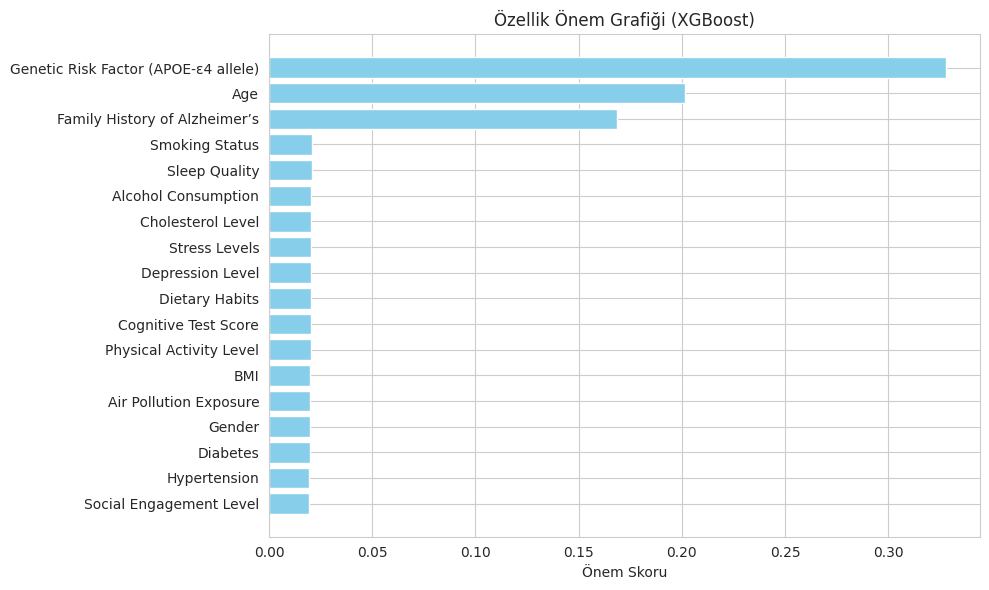


Veri Seti İstatistikleri:
Toplam örnek sayısı: 74283
Özellik sayısı: 18
Sınıf dağılımı:
Alzheimer’s Diagnosis
0   0.587
1   0.413
Name: proportion, dtype: float64


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Veri setini oku
print("Veri seti okunuyor...")
df = pd.read_csv('alzheimers_prediction_dataset.csv')

# Gereksiz sütunları çıkar (varsa)
columns_to_drop = [
    "Country", "Employment Status", "Marital Status",
    "Income Level", "Urban vs Rural Living", "Education Level"
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Veri seti bilgileri
print("\nVeri seti boyutu:", df.shape)
print("\nVeri seti sütunları:")
print(df.columns.tolist())

# Hedef sütunu otomatik bul
target_column = [col for col in df.columns if "diagnosis" in col.lower()]
if not target_column:
    raise ValueError("Hedef sütun (örneğin 'Alzheimer’s Diagnosis') bulunamadı.")
target_column = target_column[0]
print(f"\nHedef değişken bulundu: {target_column}")

# Object tipindeki sütunları LabelEncode et
categorical_columns = df.select_dtypes(include='object').columns.tolist()
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

le = LabelEncoder()
for col in categorical_columns + [target_column]:
    df[col] = le.fit_transform(df[col].astype(str))

# Sayısal verileri normalize et (isteğe bağlı ama faydalı olabilir)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_columns = [col for col in numerical_columns if col != target_column]
for col in numerical_columns:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Özellikler ve hedefi ayır
X = df.drop(target_column, axis=1)
y = df[target_column]

# Eğitim ve test veri setine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli tanımla ve eğit
print("\nModel eğitiliyor...")
model = XGBClassifier(random_state=42, use_label_encoder=False)
model.fit(X_train, y_train)

# Tahmin yap ve değerlendirme metrikleri
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"\nF1 Score: {f1:.2f}")
print(f"Accuracy: {acc:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Modeli kaydet
print("\nModel kaydediliyor...")
model.save_model('alzheimer_model.json')
print("Model başarıyla kaydedildi: alzheimer_model.json")

# Özellik önem sıralaması
importance = model.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({'feature': features, 'importance': importance})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print("\nÖzellik Önem Sıralaması:")
for i, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Görselleştirme: Özellik önem grafiği
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Önem Skoru')
plt.title('Özellik Önem Grafiği (XGBoost)')
plt.tight_layout()
plt.show()

# Veri seti istatistikleri
print("\nVeri Seti İstatistikleri:")
print(f"Toplam örnek sayısı: {len(df)}")
print(f"Özellik sayısı: {len(X.columns)}")
print(f"Sınıf dağılımı:\n{df[target_column].value_counts(normalize=True)}")


# **Risk Tahmin Formu**

In [74]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Risk faktör katsayıları
risk_factors = {
    'genetic_risk': {'no': 0.3658, 'yes': 0.6061},
    'family_history': {'no': 0.3680, 'yes': 0.5195},
    'physical_activity': {'high': 0.4156, 'low': 0.4128, 'medium': 0.4120},
    'smoking_status': {'current': 0.4117, 'former': 0.4126, 'never': 0.4161},
    'alcohol_consumption': {'never': 0.4105, 'occasionally': 0.4173, 'regularly': 0.4126},
    'stress_level': {'high': 0.4171, 'low': 0.4118, 'medium': 0.4115},
    'social_engagement': {'high': 0.4113, 'low': 0.4149, 'medium': 0.4142},
    'dietary_habits': {'average': 0.4126, 'healthy': 0.4113, 'unhealthy': 0.4165},
    'sleep_quality': {'average': 0.4134, 'good': 0.4128, 'poor': 0.4142},
    'depression_level': {'high': 0.4147, 'low': 0.4141, 'medium': 0.4115},
    'cholesterol_level': {'high': 0.4119, 'normal': 0.4141},
    'hypertension': {'no': 0.4138, 'yes': 0.4126},
    'diabetes': {'no': 0.4141, 'yes': 0.4108},
    'gender': {'male': 0.4144, 'female': 0.4128},
    'air_pollution': {'high': 0.4118, 'low': 0.4167, 'medium': 0.4119}
}

# Geçerli girdi değerleri
valid_inputs = {
    'gender': ['male', 'female'],
    'physical_activity': ['high', 'medium', 'low'],
    'smoking_status': ['current', 'former', 'never'],
    'alcohol_consumption': ['regularly', 'occasionally', 'never'],
    'diabetes': ['yes', 'no'],
    'hypertension': ['yes', 'no'],
    'cholesterol_level': ['high', 'normal'],
    'family_history': ['yes', 'no'],
    'depression_level': ['high', 'medium', 'low'],
    'sleep_quality': ['poor', 'average', 'good'],
    'dietary_habits': ['unhealthy', 'average', 'healthy'],
    'air_pollution': ['high', 'medium', 'low'],
    'genetic_risk': ['yes', 'no'],
    'social_engagement': ['low', 'medium', 'high'],
    'stress_level': ['high', 'medium', 'low']
}

# BMI ve Cognitive score için aralık değerleri
bmi_ranges = {
    (18, 20): 0.4118, (20, 22): 0.4160, (22, 24): 0.4165,
    (24, 26): 0.4133, (26, 28): 0.4090, (28, 30): 0.4183,
    (30, 32): 0.4076, (32, 34): 0.4165, (34, 36): 0.4101
}

cognitive_ranges = {
    (30, 40): 0.4146, (40, 50): 0.4170, (50, 60): 0.4115,
    (60, 70): 0.4132, (70, 80): 0.4096, (80, 90): 0.4144,
    (90, 100): 0.4139
}

# Risk ağırlıkları
risk_weights = {
    'cholesterol_level': 0.0203,
    'gender': 0.0199,
    'depression_level': 0.0203,
    'cognitive_test_score': 0.0202,
    'social_engagement': 0.0193,
    'sleep_quality': 0.0207,
    'physical_activity': 0.0201,
    'smoking_status': 0.0209,
    'dietary_habits': 0.0202,
    'alcohol_consumption': 0.0204,
    'air_pollution': 0.0200,
    'diabetes': 0.0198,
    'hypertension': 0.0194,
    'genetic_risk': 0.3280,
    'stress_level': 0.0203,
    'family_history': 0.1684,
    'age': 0.2017,
    'bmi': 0.0200
}

def validate_input(prompt, valid_values):
    """Girdi doğrulama fonksiyonu"""
    while True:
        value = input(prompt).lower()
        if value in valid_values:
            return value
        print(f"Hatalı girdi! Lütfen şu değerlerden birini girin: {', '.join(valid_values)}")

def validate_numeric_input(prompt, min_val, max_val):
    """Sayısal değer doğrulama fonksiyonu"""
    while True:
        try:
            value = float(input(prompt))
            if min_val <= value <= max_val:
                return value
            print(f"Lütfen {min_val} ile {max_val} arasında bir değer girin.")
        except ValueError:
            print("Lütfen geçerli bir sayı girin.")

def get_range_value(value, ranges):
    """Sayısal değerler için aralık değeri bulma"""
    for (lower, upper), factor in ranges.items():
        if lower <= value <= upper:
            return factor
    return 0.4  # Default değer

def calculate_weighted_risk(form_input):
    """Ağırlıklı risk hesaplama"""
    total_risk = 0
    total_weight = 0

    # Kategorik değerler için risk hesaplama
    for factor, value in form_input.items():
        if factor in risk_factors:
            risk_value = risk_factors[factor][value.lower()]
            weight = risk_weights.get(factor, 0.04)
            total_risk += risk_value * weight
            total_weight += weight

    # BMI için risk hesaplama
    bmi = float(form_input['bmi'])
    bmi_risk = get_range_value(bmi, bmi_ranges)
    total_risk += bmi_risk * risk_weights['bmi']
    total_weight += risk_weights['bmi']

    # Cognitive score için risk hesaplama
    cognitive = float(form_input['cognitive_test_score'])
    cognitive_risk = get_range_value(cognitive, cognitive_ranges)
    total_risk += cognitive_risk * risk_weights['cognitive_test_score']
    total_weight += risk_weights['cognitive_test_score']

    # Normalize risk
    normalized_risk = (total_risk / total_weight) * 100
    return normalized_risk

def calculate_density_based_risk(form_input):
    """Density bazlı risk hesaplama"""
    total_density = 0

    # Kategorik değerler için density hesaplama
    for factor, value in form_input.items():
        if factor in risk_factors:
            density = risk_factors[factor][value.lower()]
            total_density += density

    # BMI için density hesaplama
    bmi = float(form_input['bmi'])
    bmi_density = get_range_value(bmi, bmi_ranges)
    total_density += bmi_density

    # Cognitive score için density hesaplama
    cognitive = float(form_input['cognitive_test_score'])
    cognitive_density = get_range_value(cognitive, cognitive_ranges)
    total_density += cognitive_density

    # Normalize density
    return (total_density / (len(risk_factors) + 2)) * 100  # +2 for bmi and cognitive

def prepare_input_for_model(form_input):
    """Form girdisini model için hazırla"""
    # Veri setindeki sütun sırasına göre feature'ları hazırla
    input_data = []

    # Sayısal değerleri ekle
    input_data.append(float(form_input['age']))  # Age

    # Gender
    input_data.append(1 if form_input['gender'].lower() == 'male' else 0)

    # BMI
    input_data.append(float(form_input['bmi']))

    # Physical Activity Level
    activity_map = {'high': 2, 'medium': 1, 'low': 0}
    input_data.append(activity_map[form_input['physical_activity'].lower()])

    # Smoking Status
    smoking_map = {'current': 2, 'former': 1, 'never': 0}
    input_data.append(smoking_map[form_input['smoking_status'].lower()])

    # Alcohol Consumption
    alcohol_map = {'regularly': 2, 'occasionally': 1, 'never': 0}
    input_data.append(alcohol_map[form_input['alcohol_consumption'].lower()])

    # Binary değerler
    input_data.append(1 if form_input['diabetes'].lower() == 'yes' else 0)
    input_data.append(1 if form_input['hypertension'].lower() == 'yes' else 0)
    input_data.append(1 if form_input['cholesterol_level'].lower() == 'high' else 0)
    input_data.append(1 if form_input['family_history'].lower() == 'yes' else 0)

    # Cognitive Test Score
    input_data.append(float(form_input['cognitive_test_score']))

    # Depression Level
    level_map = {'high': 2, 'medium': 1, 'low': 0}
    input_data.append(level_map[form_input['depression_level'].lower()])

    # Sleep Quality
    quality_map = {'poor': 2, 'average': 1, 'good': 0}
    input_data.append(quality_map[form_input['sleep_quality'].lower()])

    # Dietary Habits
    diet_map = {'unhealthy': 2, 'average': 1, 'healthy': 0}
    input_data.append(diet_map[form_input['dietary_habits'].lower()])

    # Air Pollution
    pollution_map = {'high': 2, 'medium': 1, 'low': 0}
    input_data.append(pollution_map[form_input['air_pollution'].lower()])

    # Genetic Risk
    input_data.append(1 if form_input['genetic_risk'].lower() == 'yes' else 0)

    # Social Engagement
    engagement_map = {'low': 2, 'medium': 1, 'high': 0}
    input_data.append(engagement_map[form_input['social_engagement'].lower()])

    # Stress Level
    stress_map = {'high': 2, 'medium': 1, 'low': 0}
    input_data.append(stress_map[form_input['stress_level'].lower()])

    return np.array(input_data).reshape(1, -1)

def calculate_model_based_risk(form_input, model):
    """Model bazlı risk hesaplama"""
    try:
        X = prepare_input_for_model(form_input)
        return model.predict_proba(X)[0][1] * 100
    except Exception as e:
        print(f"Model bazlı risk hesaplama hatası: {e}")
        return None

def calculate_final_risk(weighted_risk, density_risk, model_risk=None):
    """Final risk hesaplama"""
    if model_risk is not None:
        # Tüm risk türlerini kombine et
        return (0.33 * weighted_risk + 0.33 * density_risk + 0.34 * model_risk)
    else:
        # Model riski yoksa weighted ve density'yi kombine et
        return (0.5 * weighted_risk + 0.5 * density_risk)

# Ana program
print("Alzheimer Risk Değerlendirme Formu")
print("----------------------------------")

# XGBoost modelini yükle
try:
    model = xgb.XGBClassifier()
    model.load_model('alzheimer_model.json')
    print("Model başarıyla yüklendi.")
except Exception as e:
    print(f"Model yükleme hatası: {e}")
    print("Model yüklenemedi. Model tahmini olmadan devam edilecek.")
    model = None

# Form girdilerini al
form_input = {}

# Kategorik değerler için input al
for factor, values in valid_inputs.items():
    form_input[factor] = validate_input(f"{factor.replace('_', ' ').title()} ({'/'.join(values)}): ", values)

# Sayısal değerler için input al
form_input['age'] = validate_numeric_input("Yaş (0-120): ", 0, 120)
form_input['bmi'] = validate_numeric_input("BMI (10-50): ", 10, 50)
form_input['cognitive_test_score'] = validate_numeric_input("Kognitif Test Skoru (0-100): ", 0, 100)

try:
    # Tüm risk hesaplamalarını yap
    weighted_risk = calculate_weighted_risk(form_input)
    density_risk = calculate_density_based_risk(form_input)
    model_risk = calculate_model_based_risk(form_input, model) if model is not None else None

    # Final risk hesaplama
    final_risk = calculate_final_risk(weighted_risk, density_risk, model_risk)

    print("\n🔍 Alzheimer Risk Değerlendirmesi:")
    print(f"1. Ağırlıklı Risk: %{weighted_risk:.2f}")
    print(f"2. Density-based Risk: %{density_risk:.2f}")
    if model_risk is not None:
        print(f"3. Model-based Risk: %{model_risk:.2f}")
    print(f"\nFinal Risk Değeri: %{final_risk:.2f}")

    # Risk kategorisi ve açıklama
    if final_risk < 25:
        risk_category = "Düşük Risk"
        explanation = "Alzheimer riski düşük görünüyor. Sağlıklı yaşam tarzını sürdürün."
    elif final_risk < 50:
        risk_category = "Orta Risk"
        explanation = "Risk orta seviyede. Önleyici tedbirler almaya başlayabilirsiniz."
    elif final_risk < 75:
        risk_category = "Yüksek Risk"
        explanation = "Risk yüksek seviyede. Bir sağlık uzmanına danışmanız önerilir."
    else:
        risk_category = "Çok Yüksek Risk"
        explanation = "Risk çok yüksek seviyede. En kısa zamanda bir nörologa başvurun."

    print(f"\nRisk Kategorisi: {risk_category}")
    print(f"Değerlendirme: {explanation}")

    # Risk faktörleri analizi
    print("\nDetaylı Risk Faktörleri Analizi:")

    print("\n1. Ağırlıklı Risk Faktörleri:")
    risk_factors_analysis = []
    for factor, value in form_input.items():
        if factor in risk_factors:
            risk_value = risk_factors[factor][value.lower()]
            weight = risk_weights.get(factor, 0.04)
            weighted_factor_risk = risk_value * weight
            risk_factors_analysis.append((factor, weighted_factor_risk, value))

    risk_factors_analysis.sort(key=lambda x: x[1], reverse=True)
    for factor, risk, value in risk_factors_analysis[:5]:
        print(f"- {factor.replace('_', ' ').title()}: {value} (Risk Katkısı: {risk:.4f})")

    print("\n2. Density-based Risk Faktörleri:")
    density_analysis = []
    for factor, value in form_input.items():
        if factor in risk_factors:
            density = risk_factors[factor][value.lower()]
            density_analysis.append((factor, density, value))

    density_analysis.sort(key=lambda x: x[1], reverse=True)
    for factor, density, value in density_analysis[:5]:
        print(f"- {factor.replace('_', ' ').title()}: {value} (Density: {density:.4f})")

except Exception as e:
    print(f"Hata oluştu: {e}")
    if 'X' in locals():
        print("Model girdi boyutları:", X.shape)
    else:
        print("X oluşturulmadı")

Alzheimer Risk Değerlendirme Formu
----------------------------------
Model başarıyla yüklendi.
Gender (male/female): male
Physical Activity (high/medium/low): high
Smoking Status (current/former/never): current
Alcohol Consumption (regularly/occasionally/never): never
Diabetes (yes/no): yes
Hypertension (yes/no): yes
Cholesterol Level (high/normal): normal
Family History (yes/no): yes
Depression Level (high/medium/low): low
Sleep Quality (poor/average/good): poor
Dietary Habits (unhealthy/average/healthy): average
Air Pollution (high/medium/low): low
Genetic Risk (yes/no): yes
Social Engagement (low/medium/high): low
Stress Level (high/medium/low): low
Yaş (0-120): 120
BMI (10-50): 50
Kognitif Test Skoru (0-100): 100

🔍 Alzheimer Risk Değerlendirmesi:
1. Ağırlıklı Risk: %51.46
2. Density-based Risk: %43.02
3. Model-based Risk: %54.38

Final Risk Değeri: %49.67

Risk Kategorisi: Orta Risk
Değerlendirme: Risk orta seviyede. Önleyici tedbirler almaya başlayabilirsiniz.

Detaylı Risk Fakt

# **SONUÇLAR**

Bu çalışmada, Alzheimer hastalığını etkileyebilecek çeşitli bireysel, çevresel, genetik ve davranışsal faktörler üzerinde kapsamlı bir analiz gerçekleştirilmiştir. Analiz kapsamında toplam 19 değişken incelenmiş ve her bir değişkenin Alzheimer hastalığı ile olan ilişkisi değerlendirilmiştir. Bulgular, istatistiksel analizler ve görselleştirme teknikleriyle desteklenmiştir. Ayrıca, bireysel risk tahmini yapılabilmesi için XGBoost tabanlı bir makine öğrenimi modeli geliştirilmiş ve bu model ile kişiselleştirilmiş risk öngörüsü sağlanmıştır.

📌 Veri Setine Dayalı Bulguların Özeti
Bu çalışmada yapılan analizler sonucunda, Alzheimer hastalığı ile doğrudan anlamlı ve güçlü ilişkili olan yalnızca üç temel değişken tespit edilmiştir:

Age (Yaş): Yaş ilerledikçe Alzheimer’a yakalanma riski belirgin şekilde artmaktadır. Özellikle ileri yaş grubundaki bireylerde teşhis oranları anlamlı biçimde yüksektir.

Genetic Risk Factor (APOE-ε4 allele): APOE-ε4 gen varyantına sahip bireylerde Alzheimer riski, bu varyanta sahip olmayanlara göre oldukça yüksektir. Genetik yatkınlık, hastalığın gelişiminde temel belirleyicilerden biridir.

Family History of Alzheimer’s: Ailede Alzheimer öyküsü olan bireylerin hastalığa yakalanma olasılığı istatistiksel olarak anlamlı biçimde artmıştır. Bu durum, genetik ve çevresel ortak faktörlerin etkisini göstermektedir.

Bu üç değişken dışında kalan; cinsiyet, vücut kitle indeksi, fiziksel aktivite, sigara kullanımı, alkol tüketimi, diyabet, hipertansiyon, kolesterol seviyesi, depresyon düzeyi, uyku kalitesi, beslenme alışkanlıkları, hava kirliliği maruziyeti, sosyal etkileşim düzeyi ve stres seviyesi gibi faktörlerin her biri incelenmiş ancak veri setine göre istatistiksel olarak anlamlı bir etki göstermemiştir. Bu değişkenlerin Alzheimer riski üzerinde dolaylı etkileri olabilir; ancak mevcut veri seti bu ilişkileri destekleyecek kadar güçlü bir bağ ortaya koymamıştır.

Dolayısıyla bu çalışmanın bulgularına göre, yaş, genetik faktör (APOE-ε4) ve aile geçmişi Alzheimer hastalığı için en belirgin risk faktörleri olarak öne çıkarken, diğer değişkenlerin tek başlarına belirleyici olmadığı sonucuna varılmıştır.

📈 Model Performansı ve Kişisel Risk Tahmini
Elde edilen verilerle XGBoost algoritması kullanılarak eğitimli bir model geliştirilmiş ve bu model ile bireylerin sahip olduğu özelliklere göre Alzheimer riski tahmin edilebilir hale getirilmiştir. Ayrıca, her kategorik değişken için kendi içinde yoğunluk (density) oranları hesaplanarak, hangi sınıfların daha yüksek risk taşıdığı grafiksel olarak gösterilmiştir.